# Data Quality Report — WerkExpert Dataset
**Stageopdracht:** Rovecom Terra | **Auteur:** Sam Berkhout

Dit notebook onderzoekt de datakwaliteit van de WerkExpert-dataset als trainingsdata voor:
- **Model 1** — Tijdsvoorspelling (hoelang duurt een taak?)
- **Model 2** — Resource-matching (welke medewerker past bij welke activiteit?)

De analyses zijn gestructureerd langs vijf ISO 25012 datakwaliteitsdimensies:
1. **Volledigheid** — Zijn de kernvelden gevuld?
2. **Consistentie** — Kloppen foreign keys en waarden?
3. **Nauwkeurigheid** — Zijn de waarden realistisch?
4. **Tijdigheid** — Is de data actueel en zonder gaten?
5. **Bruikbaarheid** — Welke features zijn bruikbaar voor de modellen?

De bevindingen zijn beschreven in het bijbehorende **Data Quality Report**.


## 0. Setup en imports

We laden alle benodigde libraries en configureren een bugfix voor de Firebird-driver.
De `firebirdsql`-driver crasht soms op WIN1252 tekens — de patch hieronder vangt dat af.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.ticker as mticker


**Bugfix — WIN1252 decoding:** `firebirdsql` crasht soms op tekens die niet in UTF-8 passen (bijv. Nederlandse speciaaltekens in de Firebird WIN1252-databases). De patch hieronder vervangt onleesbare bytes door een placeholder zodat de verbinding niet afbreekt.

In [ ]:
import firebirdsql.wireprotocol as wp
from firebirdsql.consts import charset_map

_orig = wp.WireProtocol.bytes_to_str

def _safe_decode(self, b):
    charset = charset_map.get(self.charset, self.charset)
    return b.decode(charset, errors='replace')

wp.WireProtocol.bytes_to_str = _safe_decode


## 1. Verbinding met de databases

De dataset bestaat uit vijf Firebird-databases, verdeeld over twee klanten (Hulter en Kuijpers)
en meerdere jaren (2023-2025). Zie rapport §3 voor een beschrijving van de databasestructuur.


In [3]:
import firebirdsql

DATABASES = {
    '23_hulter' : '/firebird/data/HULTER_23 - kopie.GDB',
    '24_hulter' : '/firebird/data/HULTER_24 - kopie.GDB',
    '25_hulter' : '/firebird/data/HULTER_25 - kopie.GDB',
    '24_kuijpers': '/firebird/data/HOOFD_24.GDB',
    '25_kuijpers': '/firebird/data/HOOFD_25.GDB',
    '23_melse' : '/firebird/data/MELSE2023.GDB',
    '24_melse' : '/firebird/data/MELSE2024.GDB',
    '25_melse' : '/firebird/data/MELSE2025.GDB',
    '23_poel' : '/firebird/data/POEL_2023.GDB',
    '24_poel' : '/firebird/data/POEL_2024.GDB',
    '25_poel' : '/firebird/data/POEL_2025.GDB',
    '23_westra' : '/firebird/data/WESTRA_23.GDB',
    '24_westra' : '/firebird/data/WESTRA_24.GDB',
    '25_westra' : '/firebird/data/WESTRA_25.GDB',
    '23_jennissen' : '/firebird/data/jennissen_23.GDB',
    '24_jennissen' : '/firebird/data/jennissen_24.GDB',
    '25_jennissen' : '/firebird/data/jennissen_25.GDB',
    '23_derks' : '/firebird/data/DERKS_23.GDB',
    '24_derks' : '/firebird/data/DERKS_24.GDB',
    '25_derks' : '/firebird/data/DERKS_25.GDB',
    
    

}

connections = {
    naam: firebirdsql.connect(
        host='mac-mini-van-terra.local',
        port=3050,
        database=pad,
        user='SYSDBA',
        password='masterkey',
        charset='WIN1252',
    )
    for naam, pad in DATABASES.items()
}

print(f'{len(connections)} databases verbonden: {list(connections.keys())}')


ConnectionRefusedError: [Errno 61] Connection refused

In [ ]:
def fetch_combined(table_name, columns='*'):
    """
    Haalt data op uit alle databases en combineert dit in één DataFrame.
    
    De kolom 'con' geeft aan uit welke database een rij afkomstig is.
    Exacte duplicaten (zelfde rij in meerdere databases) worden verwijderd.
    """
    frames = []
    for db_name, conn in connections.items():
        df = pd.read_sql(f'SELECT {columns} FROM {table_name}', conn)
        df['con'] = db_name
        frames.append(df)
    
    combined = pd.concat(frames, ignore_index=True)
    return combined.drop_duplicates()

## 2. Volledigheid (Completeness)

**Onderzoeksvraag (rapport §4):** Zijn de kernvelden voor Model 1 en Model 2 voldoende gevuld?

We laden een eerder gegenereerde CSV met null-tellingen per tabel/kolom/database
en maken heatmaps per relevante tabel. De drempelwaarden zijn:
- **Groen** (<5% null) — geschikt voor gebruik
- **Oranje** (5-20% null) — acceptabel maar let op
- **Rood** (>20% null) — problematisch, vraagt om cleaning of imputatie

**Bevinding (rapport §4.4):** Alle kernvelden zitten boven 95%. Het enige structurele knelpunt
is de machine-koppeling (URENVERANTW_MACHID, ORD_MACHINE_ID, ORDMED_MACHID: ~100% null).


**Relevante kolommen per tabel** — alleen de velden die Model 1 of Model 2 nodig hebben worden meegenomen in de heatmaps. De volledige tabellijst staat in rapport §3.9.

In [ ]:
RELEVANTE_KOLOMMEN = {
    'TB_URENVERANTWOORDING': [
        'URENVERANTW_AANTAL', 'URENVERANTW_TIJDSOORT', 'URENVERANTW_MEDID',
        'URENVERANTW_DATUM', 'URENVERANTW_ORDDAID', 'URENVERANTW_ORDERID',
        'URENVERANTW_STARTTIJD', 'URENVERANTW_STOPTIJD', 'URENVERANTW_ONDERBREKING',
        'URENVERANTW_ONDERBR_AANTAL', 'URENVERANTW_MACHID',
    ],
    'TB_ORDER': [
        'ORD_ID', 'RELATIE_ID', 'PROJ_ID', 'LOC_ID', 'ADRES_ID',
        'ORD_SOORT', 'ORD_INVDATUM', 'ORD_UITVDATUM', 'BEWERKING_ID',
        'ORD_HOOFDMEDEWERKER', 'ORD_MACHINE_ID',
    ],
    'TB_ORDERREGEL': [
        'ORDRG_ID', 'ORDER_DA_ID', 'ORDRG_PRIJSRG_ID', 'ORDRG_HOEVEELHEID',
        'ORDRG_PLANSTART', 'ORDRG_PLANSTOP', 'ORDRG_MACHINE_ID',
    ],
    'TB_ORDER_DA':       ['ORDER_DA_ID', 'ORD_ID', 'DIENST_ART_ID'],
    'TB_DIENST_ARTIKEL': ['DIENST_ART_ID', 'DIENST_ART_CODE', 'DIENST_ART_OMS', 'DIENST_ART_TYPE', 'BEWERKING_ID'],
    'TB_PRIJS_REGEL':    ['PRIJSRG_ID', 'PRIJSRG_OMS', 'PRIJSRG_ISDIENST', 'DIENSTTYPE_ID', 'PRIJSRG_DEF_MACH_ID', 'PRIJSRG_MACHGROP_ID'],
    'TB_MACHINE':        ['MACH_ID', 'MACH_CODE', 'MACH_OMS', 'MATERIEELTYPE', 'MACH_INPLANBAAR', 'MACH_MERK', 'MACH_TYPE', 'MACH_BOUWJAAR'],
    'TB_ORD_MEDEWERKER': ['ORDMED_ID', 'ORDMED_ORDERDAID', 'ORDMED_MEDID', 'ORDMED_ORDERREGELID', 'ORDMED_PLAN_START', 'ORDMED_PLAN_STOP', 'ORDMED_MANDAGEN', 'ORDMED_MACHID', 'ORDMED_STATUS'],
    'TB_MEDEWERKER':     ['MED_ID', 'MED_NAAM', 'MED_CODE', 'MED_ISINPLANNEN', 'MED_ISMEDEWERKER', 'FUNCGRP_ID'],
    'TB_RELATIE':        ['RELATIE_ID', 'REL_NAAM', 'RELATIE_KLANTCODE'],
}


In [ ]:
# create the data_quality_report.csv for the relevant columns do if the csv not exist or is older than 1 day

records = []
for table, columns in RELEVANTE_KOLOMMEN.items():
    col_str = ', '.join(columns)
    df = fetch_combined(table, columns=col_str)
    for col in columns:
        not_null_count = df[col].notna().sum()
        null_count = df[col].isna().sum()
        records.append({
            'table': table,
            'column': col,
            'not_null_count': not_null_count,
            'null_count': null_count,
        })
    df_report = pd.DataFrame(records)
    df_report.to_csv('data_quality_report.csv', index=False)

In [ ]:
df_qual = pd.read_csv('data_quality_report.csv')

# Verwijder de 'con' kolom (die is geen echte tabelkolom maar een meta-kolom van fetch_combined)
df_qual = df_qual[df_qual['column'] != 'con']

# Bereken vulgraad per kolom
df_qual['total']      = df_qual['not_null_count'] + df_qual['null_count']
df_qual['filled_pct'] = (df_qual['not_null_count'] / df_qual['total'] * 100).round(1)
df_qual.loc[df_qual['total'] == 0, 'filled_pct'] = 0

print(f'Geladen: {df_qual["table"].nunique()} tabellen, {len(df_qual)} kolommen')


Geladen: 10 tabellen, 69 kolommen


**Relevante kolommen per tabel** — alleen de velden die Model 1 of Model 2 nodig hebben worden meegenomen in de heatmaps. De volledige tabellijst staat in rapport §3.9.

In [ ]:
def maak_volledigheid_heatmap(tabel_naam, kolommen, output_dir='.', toon=False):
    """
    Tekent een heatmap met de vulgraad per kolom voor één tabel.
    Groen = goed gevuld, rood = veel nulls.
    Slaat de figuur op als PNG (of toont hem als toon=True).
    """
    # Zoek de vulgraad op voor elke kolom
    rijen = []
    for kolom in kolommen:
        match = df_qual[(df_qual['table'] == tabel_naam) & (df_qual['column'] == kolom)]
        if not match.empty:
            rijen.append({'kolom': kolom, 'filled_pct': match.iloc[0]['filled_pct']})
    
    if not rijen:
        return None
    
    plot_df = pd.DataFrame(rijen)
    data    = plot_df['filled_pct'].values.reshape(1, -1)
    
    fig, ax = plt.subplots(figsize=(max(12, len(plot_df) * 0.8), 4))
    im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    
    ax.set_yticks([0])
    ax.set_yticklabels([tabel_naam.replace('TB_', '')], fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(plot_df['kolom'], rotation=45, ha='center', fontsize=9)
    
    for i, val in enumerate(plot_df['filled_pct']):
        if not np.isnan(val):
            kleur = 'white' if val < 40 else 'black'
            ax.text(i, 0, f'{val:.0f}%', ha='center', va='center',
                    fontsize=10, color=kleur, fontweight='bold')
    
    plt.colorbar(im, ax=ax, label='Gevuld %')
    ax.set_title(f'Volledigheid — {tabel_naam.replace("TB_", "")}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    if toon:
        plt.show()
        return None
    
    bestandsnaam = f'volledigheid_{tabel_naam.replace("TB_", "").lower()}.png'
    pad = f'{output_dir}/{bestandsnaam}' if output_dir != '.' else bestandsnaam
    plt.savefig(pad, dpi=200, bbox_inches='tight')
    plt.close()
    return bestandsnaam


**Stap 1:** Genereer de volledigheids-heatmaps en sla ze op als PNG. De bestandsnamen worden geprint zodat je weet welke figuren zijn aangemaakt.

In [ ]:
for tabel, kolommen in RELEVANTE_KOLOMMEN.items():
    bestand = maak_volledigheid_heatmap(tabel, kolommen)
    if bestand:
        print(f'Opgeslagen: {bestand}')


Opgeslagen: volledigheid_urenverantwoording.png
Opgeslagen: volledigheid_order.png
Opgeslagen: volledigheid_orderregel.png
Opgeslagen: volledigheid_order_da.png
Opgeslagen: volledigheid_dienst_artikel.png
Opgeslagen: volledigheid_prijs_regel.png
Opgeslagen: volledigheid_machine.png
Opgeslagen: volledigheid_ord_medewerker.png
Opgeslagen: volledigheid_medewerker.png
Opgeslagen: volledigheid_relatie.png


**Stap 2:** Toon alle heatmaps inline in het notebook voor directe inspectie.

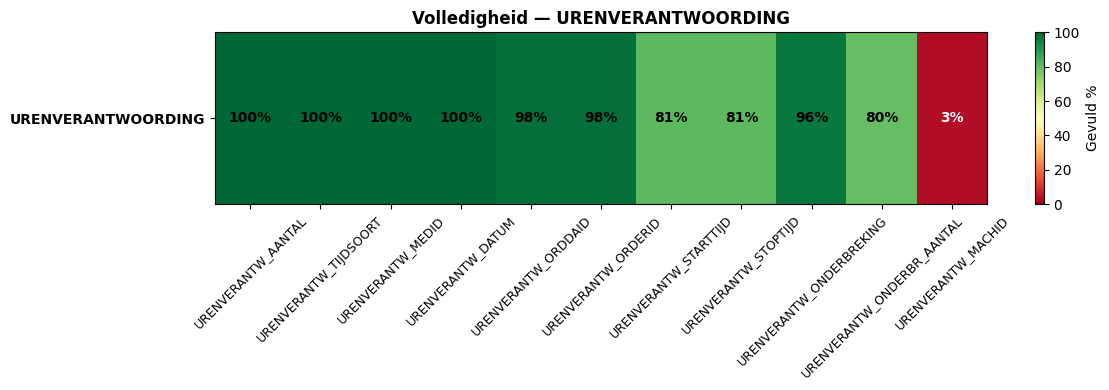

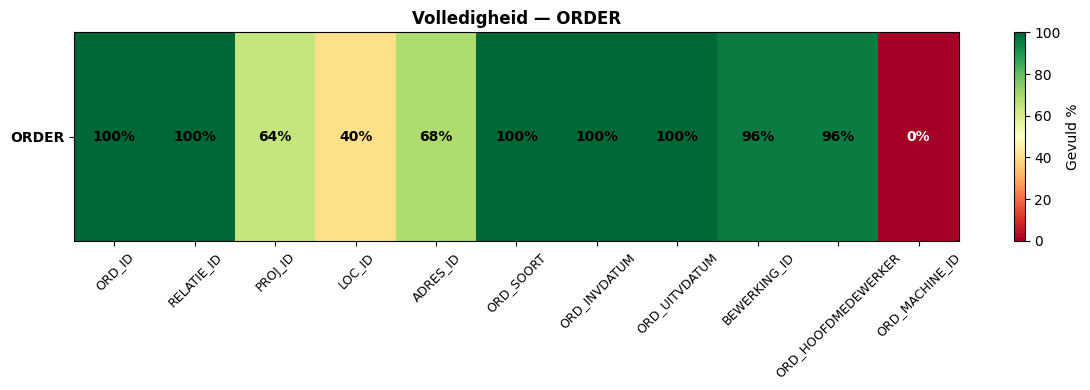

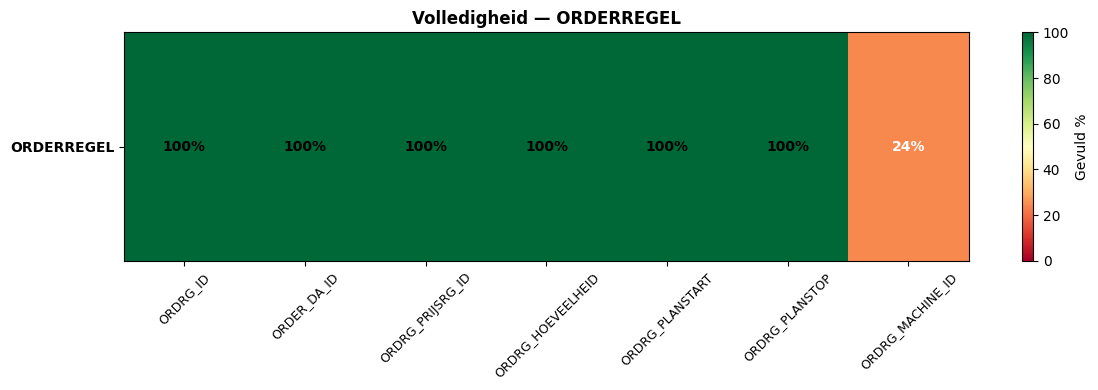

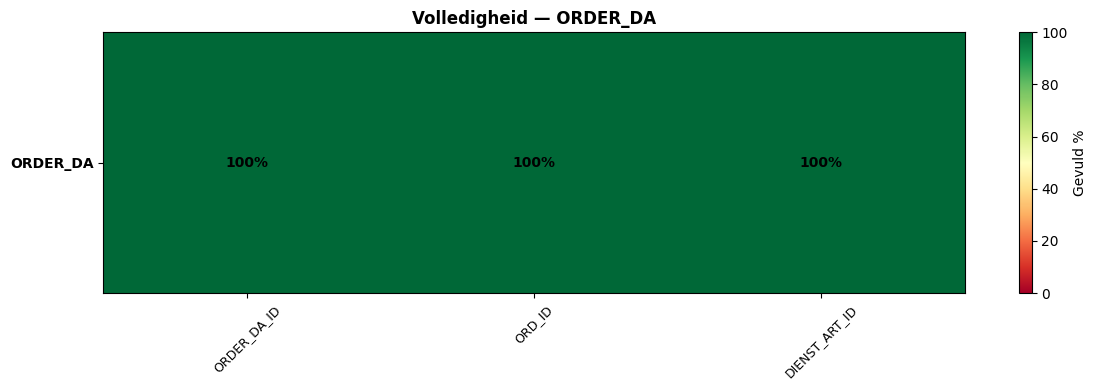

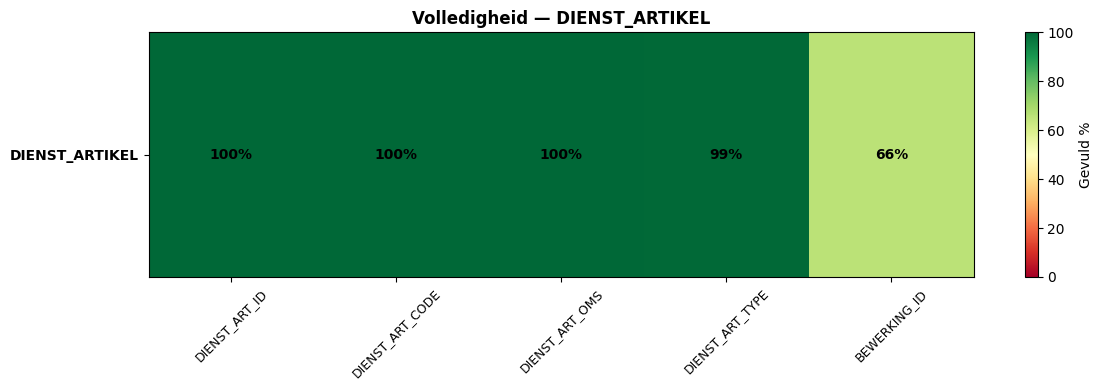

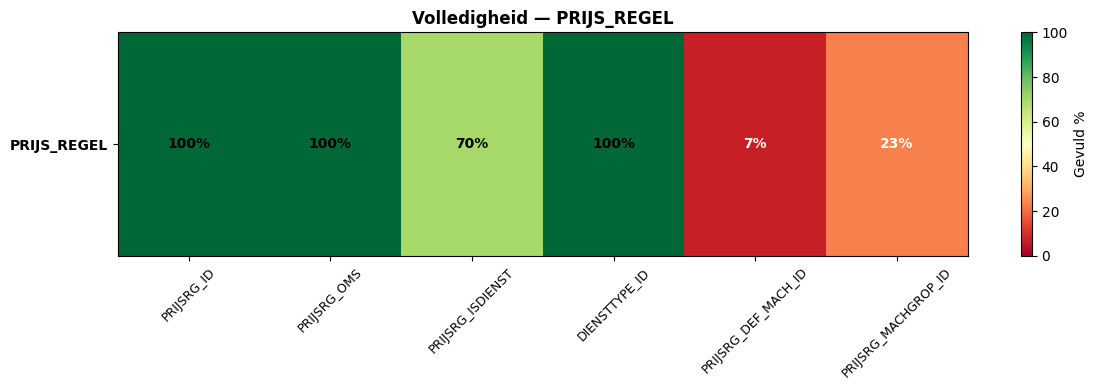

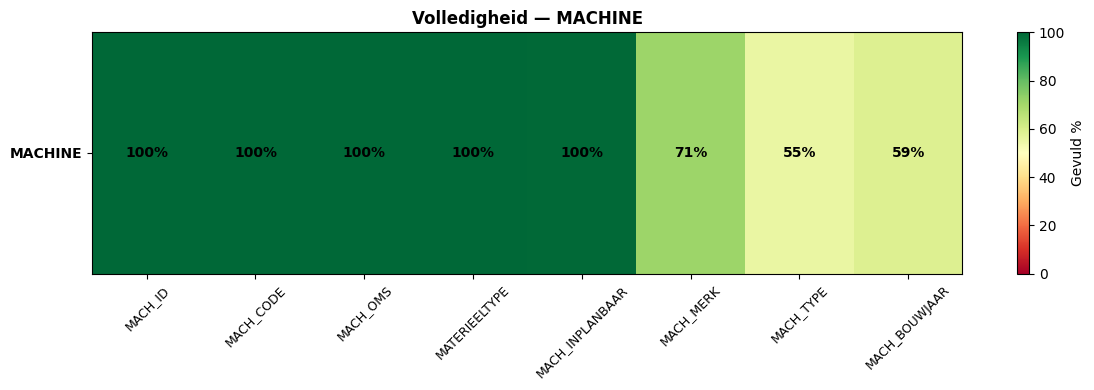

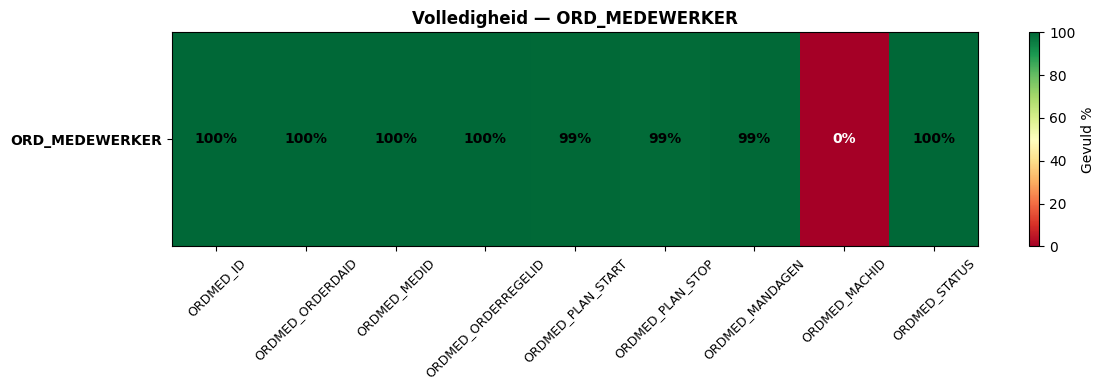

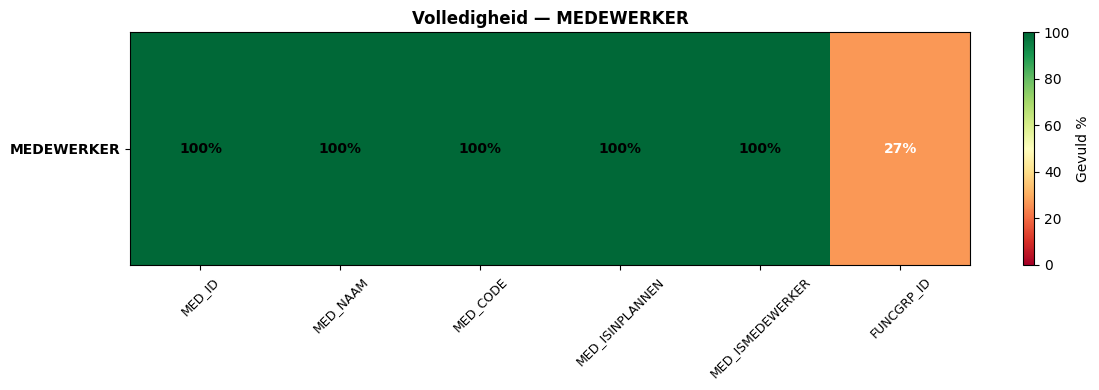

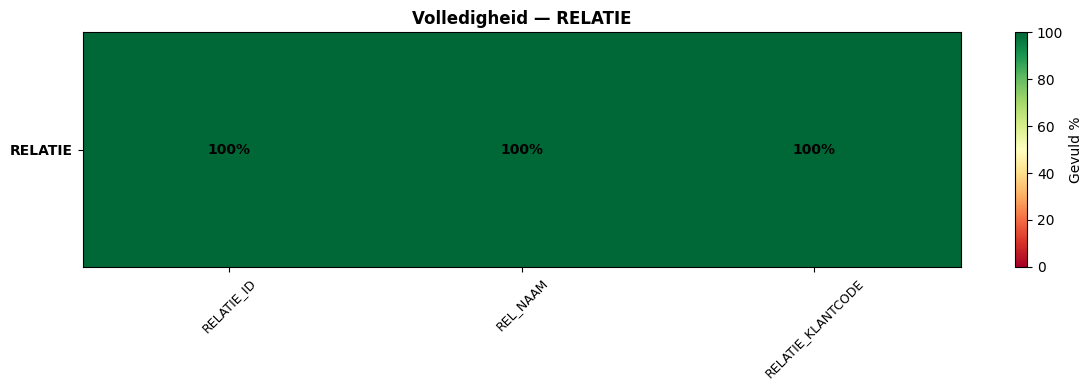

In [ ]:
for tabel, kolommen in RELEVANTE_KOLOMMEN.items():
    maak_volledigheid_heatmap(tabel, kolommen, toon=True)


## 3. Consistentie (Consistency)

**Onderzoeksvraag (rapport §5):** Zijn foreign keys intact, zijn datums logisch
en zijn waarden consistent over de vijf databases?

We voeren drie soorten checks uit:
1. **Foreign key integriteit** — bestaan alle ID-verwijzingen in de parent-tabel?
2. **Datumconsistentie** — is startdatum altijd vóór einddatum?
3. **Waardeconsistentie** — zijn er negatieve of onrealistische waarden?
4. **Duplicaten** — zijn er dubbele toewijzingen of urenregistraties?
5. **Cross-database consistentie** — hebben dezelfde IDs dezelfde namen in alle databases?

**Bevinding (rapport §5.6):** Alle 18 FK-checks zijn 100% intact. De enige aandachtspunten
zijn dubbele urenregistraties (worden samengevoegd) en ORD_INVDATUM na ORD_UITVDATUM
(bewuste registratiepraktijk, geen fout).


**Tabellen laden** — we halen alle relevante tabellen op via `fetch_combined`. Elke tabel krijgt een korte sleutelnaam (bijv. `'uren'`, `'order'`) zodat de code leesbaarder is. De kolom `'con'` geeft aan uit welke database een rij afkomstig is.

In [ ]:
TABEL_CONFIG = {
    'uren':       ('TB_URENVERANTWOORDING',
                   'URENVERANTW_ID, URENVERANTW_ORDDAID, URENVERANTW_MEDID, URENVERANTW_ORDERID, '
                   'URENVERANTW_ORDMEDID, URENVERANTW_TIJDSOORT, URENVERANTW_PROJID, '
                   'URENVERANTW_RELATIEID, URENVERANTW_AANTAL, URENVERANTW_DATUM, '
                   'URENVERANTW_STARTTIJD, URENVERANTW_STOPTIJD, URENVERANTW_MACHID'),
    'order':      ('TB_ORDER',
                   'ORD_ID, RELATIE_ID, PROJ_ID, LOC_ID, ADRES_ID, ORD_SOORT, ORD_INVDATUM, '
                   'ORD_UITVDATUM, ORD_EINDDATUM, ORD_MACHINE_ID, BEWERKING_ID, ORD_HOOFDMEDEWERKER'),
    'orderregel': ('TB_ORDERREGEL',
                   'ORDRG_ID, ORDER_DA_ID, ORDRG_PRIJSRG_ID, ORDRG_HOEVEELHEID, '
                   'ORDRG_PLANSTART, ORDRG_PLANSTOP, ORDRG_MACHINE_ID, ORD_ID'),
    'order_da':   ('TB_ORDER_DA',   'ORDER_DA_ID, ORD_ID, DIENST_ART_ID'),
    'ord_med':    ('TB_ORD_MEDEWERKER',
                   'ORDMED_ID, ORDMED_ORDERDAID, ORDMED_MEDID, ORDMED_ORDERREGELID, '
                   'ORDMED_PLAN_START, ORDMED_PLAN_STOP, ORDMED_MANDAGEN, ORDMED_MACHID'),
    'medewerker': ('TB_MEDEWERKER', 'MED_ID, MED_NAAM, MED_CODE'),
    'relatie':    ('TB_RELATIE',    'RELATIE_ID, REL_NAAM, RELATIE_KLANTCODE'),
    'machine':    ('TB_MACHINE',    'MACH_ID, MACH_CODE, MACH_OMS'),
    'dienst_art': ('TB_DIENST_ARTIKEL', 'DIENST_ART_ID, DIENST_ART_CODE, DIENST_ART_OMS'),
    'project':    ('TB_PROJECT',    'PROJ_ID, PROJ_OMS, PROJ_STARTDT'),
    'locatie':    ('TB_LOCATIE',    'LOC_ID, LOC_CODE, LOC_OMS'),
    'tijdsoort':  ('TB_TIJDSOORT',  'TIJDSOORT_ID, TIJDSOORT_OMS'),
    'prijs_regel':('TB_PRIJS_REGEL','PRIJSRG_ID, PRIJSRG_OMS, PRIJSRG_ISDIENST'),
    'adressen':   ('TB_ADRESSEN',   'ADRES_ID, ADRES_POSTCODE, ADRES_PLAATS'),
}

tabellen = {}
for key, (tbl, cols) in TABEL_CONFIG.items():
    tabellen[key] = fetch_combined(tbl, cols)
    print(f'  {tbl:<35} {len(tabellen[key]):>8,} records')


  TB_URENVERANTWOORDING                629,987 records
  TB_ORDER                             360,623 records
  TB_ORDERREGEL                        570,761 records
  TB_ORDER_DA                          514,138 records
  TB_ORD_MEDEWERKER                    347,488 records
  TB_MEDEWERKER                         11,793 records
  TB_RELATIE                            51,815 records
  TB_MACHINE                             7,292 records
  TB_DIENST_ARTIKEL                     13,279 records
  TB_PROJECT                             7,647 records
  TB_LOCATIE                            11,973 records
  TB_TIJDSOORT                             369 records
  TB_PRIJS_REGEL                        14,573 records
  TB_ADRESSEN                         3,612,773 records


### 3.1 Foreign key integriteit

We controleren 18 FK-relaties: bestaat elke ID in de child-tabel ook in de parent-tabel?
Per database controleren zodat een probleem in één database opvalt.

**Verwacht resultaat:** 0 violations — zie rapport §5.1.


**FK-definitielijst** — elke tuple beschrijft één relatie: `(child_tabel, child_kolom, parent_tabel, parent_kolom)`. De check controleert of alle gevulde child-IDs ook in de parent-tabel voorkomen.

In [ ]:
FK_CHECKS = [
    ('uren',      'URENVERANTW_ORDDAID',    'order_da',   'ORDER_DA_ID'),
    ('uren',      'URENVERANTW_MEDID',       'medewerker', 'MED_ID'),
    ('uren',      'URENVERANTW_ORDERID',     'order',      'ORD_ID'),
    ('uren',      'URENVERANTW_ORDMEDID',    'ord_med',    'ORDMED_ID'),
    ('uren',      'URENVERANTW_TIJDSOORT',   'tijdsoort',  'TIJDSOORT_ID'),
    ('uren',      'URENVERANTW_PROJID',      'project',    'PROJ_ID'),
    ('uren',      'URENVERANTW_RELATIEID',   'relatie',    'RELATIE_ID'),
    ('order_da',  'ORD_ID',                  'order',      'ORD_ID'),
    ('order_da',  'DIENST_ART_ID',           'dienst_art', 'DIENST_ART_ID'),
    ('order',     'RELATIE_ID',              'relatie',    'RELATIE_ID'),
    ('order',     'PROJ_ID',                 'project',    'PROJ_ID'),
    ('order',     'LOC_ID',                  'locatie',    'LOC_ID'),
    ('order',     'ADRES_ID',                'adressen',   'ADRES_ID'),
    ('orderregel','ORDER_DA_ID',             'order_da',   'ORDER_DA_ID'),
    ('orderregel','ORDRG_MACHINE_ID',        'machine',    'MACH_ID'),
    ('ord_med',   'ORDMED_MEDID',            'medewerker', 'MED_ID'),
    ('ord_med',   'ORDMED_ORDERDAID',        'order_da',   'ORDER_DA_ID'),
    ('ord_med',   'ORDMED_ORDERREGELID',     'orderregel', 'ORDRG_ID'),
]

check_resultaten = []

for child_key, child_col, parent_key, parent_col in FK_CHECKS:
    child_df  = tabellen[child_key]
    parent_df = tabellen[parent_key]
    
    for db in child_df['con'].unique():
        child_db  = child_df[child_df['con'] == db]
        parent_db = parent_df[parent_df['con'] == db]
        
        gevuld = child_db[child_db[child_col].notna()]
        totaal = len(gevuld)
        if totaal == 0:
            continue
        
        parent_ids = set(parent_db[parent_col].dropna())
        n_orphans  = (~gevuld[child_col].isin(parent_ids)).sum()
        pct        = round(n_orphans / totaal * 100, 2)
        
        check_resultaten.append({
            'db': db, 'type': 'FK',
            'check': f'{child_key}.{child_col} → {parent_key}.{parent_col}',
            'violations': int(n_orphans), 'totaal': totaal, 'pct': pct,
        })
        
        if n_orphans > 0:
            print(f'ISSUE [{db}]: {child_key}.{child_col} → {parent_key}.{parent_col}: '
                  f'{n_orphans}/{totaal} ({pct}%)')



### 3.2 Datumconsistentie

Startdatum moet altijd voor einddatum liggen. We checken vijf datumparen.
Uitzonderingen worden gerapporteerd maar niet altijd als fout beschouwd —
de `ORD_INVDATUM > ORD_UITVDATUM` situatie is een bekende registratiepraktijk (rapport §5.2).


In [ ]:
DATUM_CHECKS = [
    ('order',     'ORD_INVDATUM',       'ORD_UITVDATUM'),
    ('order',     'ORD_INVDATUM',       'ORD_EINDDATUM'),
    ('orderregel','ORDRG_PLANSTART',    'ORDRG_PLANSTOP'),
    ('ord_med',   'ORDMED_PLAN_START',  'ORDMED_PLAN_STOP'),
    ('uren',      'URENVERANTW_STARTTIJD', 'URENVERANTW_STOPTIJD'),
]

for tbl_key, start_col, stop_col in DATUM_CHECKS:
    df = tabellen[tbl_key]
    for db in df['con'].unique():
        db_df = df[df['con'] == db]
        
        # Alleen rijen met beide datums gevuld
        beide = db_df[db_df[start_col].notna() & db_df[stop_col].notna()]
        totaal = len(beide)
        if totaal == 0:
            continue
        
        start = pd.to_datetime(beide[start_col], errors='coerce')
        stop  = pd.to_datetime(beide[stop_col],  errors='coerce')
        n_fout = int((start > stop).sum())
        pct    = round(n_fout / totaal * 100, 2)
        
        check_resultaten.append({
            'db': db, 'type': 'DATUM',
            'check': f'{tbl_key}: {start_col} > {stop_col}',
            'violations': n_fout, 'totaal': totaal, 'pct': pct,
        })
        
        if n_fout > 0:
            print(f'ISSUE [{db}]: {tbl_key}: {start_col} > {stop_col}: '
                  f'{n_fout}/{totaal} ({pct}%)')



ISSUE [23_hulter]: order: ORD_INVDATUM > ORD_UITVDATUM: 2699/8205 (32.89%)
ISSUE [24_hulter]: order: ORD_INVDATUM > ORD_UITVDATUM: 2404/8751 (27.47%)
ISSUE [25_hulter]: order: ORD_INVDATUM > ORD_UITVDATUM: 2246/9399 (23.9%)
ISSUE [24_kuijpers]: order: ORD_INVDATUM > ORD_UITVDATUM: 2760/10950 (25.21%)
ISSUE [25_kuijpers]: order: ORD_INVDATUM > ORD_UITVDATUM: 2706/13209 (20.49%)
ISSUE [23_melse]: order: ORD_INVDATUM > ORD_UITVDATUM: 4087/28451 (14.37%)
ISSUE [24_melse]: order: ORD_INVDATUM > ORD_UITVDATUM: 3805/29783 (12.78%)
ISSUE [25_melse]: order: ORD_INVDATUM > ORD_UITVDATUM: 4013/30158 (13.31%)
ISSUE [23_poel]: order: ORD_INVDATUM > ORD_UITVDATUM: 2609/10229 (25.51%)
ISSUE [24_poel]: order: ORD_INVDATUM > ORD_UITVDATUM: 2583/10212 (25.29%)
ISSUE [25_poel]: order: ORD_INVDATUM > ORD_UITVDATUM: 2417/10113 (23.9%)
ISSUE [23_westra]: order: ORD_INVDATUM > ORD_UITVDATUM: 5993/25224 (23.76%)
ISSUE [24_westra]: order: ORD_INVDATUM > ORD_UITVDATUM: 6257/23006 (27.2%)
ISSUE [25_westra]: orde

### 3.3 Waardeconsistentie en duplicaten

We checken op onrealistische waarden (negatieve uren, uren > 24, negatieve mandagen)
en op dubbele registraties. Zie rapport §5.3 en §5.4 voor de bevindingen.


**Waardeconsistentie — uren** — we controleren op twee onmogelijke situaties: negatieve uren (duidt op een correciteboeking of invoerfout) en registraties boven 24 uur (onmogelijk per dag). Daarna doen we hetzelfde voor negatieve mandagen in `TB_ORD_MEDEWERKER`; die zijn waarschijnlijk correctieboekingen (rapport §5.3 en §9.4).

In [ ]:
for db in tabellen['uren']['con'].unique():
    db_df  = tabellen['uren'][tabellen['uren']['con'] == db]
    totaal = len(db_df)
    
    for check_label, masker in [
        ('uren: negatief', db_df['URENVERANTW_AANTAL'] < 0),
        ('uren: > 24 uur', db_df['URENVERANTW_AANTAL'] > 24),
    ]:
        n = int(masker.sum())
        pct = round(n / totaal * 100, 2)
        check_resultaten.append({'db': db, 'type': 'WAARDE', 'check': check_label,
                                  'violations': n, 'totaal': totaal, 'pct': pct})
        if n > 0:
            print(f'ISSUE [{db}]: {check_label}: {n}/{totaal} ({pct}%)')

# Negatieve mandagen (zijn correctieboekingen — zie rapport §9.4)
for db in tabellen['ord_med']['con'].unique():
    db_df  = tabellen['ord_med'][tabellen['ord_med']['con'] == db]
    totaal = len(db_df)
    n      = int((db_df['ORDMED_MANDAGEN'] < 0).sum())
    pct    = round(n / totaal * 100, 2)
    check_resultaten.append({'db': db, 'type': 'WAARDE', 'check': 'ord_med: negatieve mandagen',
                              'violations': n, 'totaal': totaal, 'pct': pct})
    if n > 0:
        print(f'ISSUE [{db}]: ord_med: negatieve mandagen: {n}/{totaal} ({pct}%)')

# Dubbele urenregistraties per medewerker/order_da/datum (worden samengevoegd in cleaning)
for db in tabellen['uren']['con'].unique():
    db_df  = tabellen['uren'][tabellen['uren']['con'] == db]
    subset = db_df.dropna(subset=['URENVERANTW_ORDDAID', 'URENVERANTW_MEDID', 'URENVERANTW_DATUM'])
    groepen = subset.groupby(['URENVERANTW_ORDDAID', 'URENVERANTW_MEDID', 'URENVERANTW_DATUM']).size()
    n_dup   = int((groepen > 1).sum())
    check_resultaten.append({'db': db, 'type': 'DUPLICAAT',
                              'check': 'uren: dubbel (orddaid + medid + datum)',
                              'violations': n_dup, 'totaal': len(subset), 'pct': '-'})
    if n_dup > 0:
        print(f'ISSUE [{db}]: {n_dup} dubbele urenregistraties')



ISSUE [23_hulter]: uren: > 24 uur: 3/9621 (0.03%)
ISSUE [24_hulter]: uren: > 24 uur: 2/10629 (0.02%)
ISSUE [25_hulter]: uren: negatief: 1/11194 (0.01%)
ISSUE [25_hulter]: uren: > 24 uur: 1/11194 (0.01%)
ISSUE [24_kuijpers]: uren: negatief: 1/32429 (0.0%)
ISSUE [24_kuijpers]: uren: > 24 uur: 2/32429 (0.01%)
ISSUE [25_kuijpers]: uren: > 24 uur: 3/36188 (0.01%)
ISSUE [23_melse]: uren: negatief: 7/30591 (0.02%)
ISSUE [23_melse]: uren: > 24 uur: 6/30591 (0.02%)
ISSUE [24_melse]: uren: negatief: 7/32818 (0.02%)
ISSUE [24_melse]: uren: > 24 uur: 7/32818 (0.02%)
ISSUE [25_melse]: uren: negatief: 9/34442 (0.03%)
ISSUE [25_melse]: uren: > 24 uur: 4/34442 (0.01%)
ISSUE [24_poel]: uren: negatief: 5/12153 (0.04%)
ISSUE [24_poel]: uren: > 24 uur: 2/12153 (0.02%)
ISSUE [25_poel]: uren: negatief: 1/13159 (0.01%)
ISSUE [25_poel]: uren: > 24 uur: 5/13159 (0.04%)
ISSUE [23_westra]: uren: negatief: 2/37770 (0.01%)
ISSUE [23_westra]: uren: > 24 uur: 14/37770 (0.04%)
ISSUE [24_westra]: uren: negatief: 1/340

### 3.4 Cross-database consistentie

Dezelfde ID moet in alle databases dezelfde naam hebben.
Inconsistenties duiden op hernoemingen of invoerfouten. Zie rapport §5.5.


**Cross-database check** — hetzelfde ID moet in alle vijf databases dezelfde naam hebben. Een afwijking duidt op een hernoeming of invoerfout. We tonen de eerste vijf conflicterende voorbeelden per entiteit.

In [ ]:
CROSS_CHECKS = [
    ('medewerker', 'MED_ID',       'MED_NAAM'),
    ('machine',    'MACH_ID',      'MACH_OMS'),
    ('dienst_art', 'DIENST_ART_ID','DIENST_ART_OMS'),
    ('relatie',    'RELATIE_ID',   'REL_NAAM'),
]

for tbl_key, id_col, naam_col in CROSS_CHECKS:
    df = tabellen[tbl_key]
    namen_per_id = df.groupby(id_col)[naam_col].nunique()
    n_inconsistent = int((namen_per_id > 1).sum())
    totaal_ids     = len(namen_per_id)
    
    check_resultaten.append({
        'db': 'CROSS', 'type': 'CROSS_DB',
        'check': f'{tbl_key}: {id_col} vs {naam_col}',
        'violations': n_inconsistent, 'totaal': totaal_ids,
        'pct': round(n_inconsistent / totaal_ids * 100, 2) if totaal_ids else 0,
    })
    
    if n_inconsistent > 0:
        print(f'ISSUE {tbl_key}: {n_inconsistent}/{totaal_ids} IDs met verschillende namen')
        # Toon de eerste 5 voorbeelden
        for id_val in namen_per_id[namen_per_id > 1].index[:5]:
            namen = df[df[id_col] == id_val][[naam_col, 'con']].drop_duplicates()
            print(f'  {id_col}={id_val}: {dict(zip(namen["con"], namen[naam_col]))}')
    else:
        print(f'OK {tbl_key}: alle {totaal_ids} IDs consistent over alle databases')


ISSUE medewerker: 1442/2519 IDs met verschillende namen
  MED_ID=10: {'24_kuijpers': 'Kuijpers', '25_kuijpers': 'Kuijpers', '23_poel': 'Wit', '24_poel': 'Wit', '25_poel': 'Wit', '23_westra': 'Hoekstra', '24_westra': 'Hoekstra', '25_westra': 'Hoekstra'}
  MED_ID=11: {'24_kuijpers': 'Kuijpers', '25_kuijpers': 'Kuijpers', '23_poel': 'Leijden', '24_poel': 'Leijden', '25_poel': 'Leijden', '23_westra': 'Berg', '24_westra': 'Berg', '25_westra': 'Berg'}
  MED_ID=15: {'24_kuijpers': 'Guns', '25_kuijpers': 'Guns', '23_poel': 'Brugman', '24_poel': 'Brugman', '25_poel': 'Brugman'}
  MED_ID=16: {'24_kuijpers': 'Wijffelaars', '25_kuijpers': 'Wijffelaars', '23_poel': 'Goddijn', '24_poel': 'Goddijn', '25_poel': 'Goddijn', '23_westra': 'Heslinga', '24_westra': 'Heslinga', '25_westra': 'Heslinga'}
  MED_ID=17: {'23_poel': 'Heemskerk', '24_poel': 'Heemskerk', '25_poel': 'Heemskerk', '23_westra': 'Kamstra', '24_westra': 'Kamstra', '25_westra': 'Kamstra'}
ISSUE machine: 911/1922 IDs met verschillende namen

**Samenvattend overzicht** — alle consistency-resultaten worden gecombineerd in één DataFrame. Alleen de regels met minstens één violation worden getoond.

In [ ]:
df_checks = pd.DataFrame(check_resultaten)
issues    = df_checks[df_checks['violations'].astype(str).str.replace('-','0').astype(float) > 0]

print(f'Totaal {len(df_checks)} checks uitgevoerd — {len(issues)} met violations:')
if not issues.empty:
    print(issues[['db','type','check','violations','totaal','pct']].to_string(index=False))
else:
    print('Geen issues gevonden.')


Totaal 541 checks uitgevoerd — 112 met violations:
          db      type                                              check  violations  totaal    pct
   23_hulter     DATUM                order: ORD_INVDATUM > ORD_UITVDATUM        2699    8205  32.89
   24_hulter     DATUM                order: ORD_INVDATUM > ORD_UITVDATUM        2404    8751  27.47
   25_hulter     DATUM                order: ORD_INVDATUM > ORD_UITVDATUM        2246    9399   23.9
 24_kuijpers     DATUM                order: ORD_INVDATUM > ORD_UITVDATUM        2760   10950  25.21
 25_kuijpers     DATUM                order: ORD_INVDATUM > ORD_UITVDATUM        2706   13209  20.49
    23_melse     DATUM                order: ORD_INVDATUM > ORD_UITVDATUM        4087   28451  14.37
    24_melse     DATUM                order: ORD_INVDATUM > ORD_UITVDATUM        3805   29783  12.78
    25_melse     DATUM                order: ORD_INVDATUM > ORD_UITVDATUM        4013   30158  13.31
     23_poel     DATUM                or

## 4. Nauwkeurigheid (Accuracy)

**Onderzoeksvraag (rapport §6):** Zijn de waarden realistisch en vrij van onmogelijke uitschieters?

Vier deelanalyses:
1. **Datumbereik** — records buiten 2023-2025
2. **Taakoverlap** — medewerker op twee plekken tegelijk
3. **Duurverdeling** — uitbijters in gewerkte uren en mandagen
4. **Machine-koppeling via TF-IDF** — alternatief voor lege machine-velden


### 4.1 Datumbereik — records buiten 2023–2025

Records voor 2023 of na 2025 wijzen op epoch-placeholders of datafouten.
Zie rapport §6.1 voor de bevindingen.


In [ ]:
DATE_MIN = pd.Timestamp('2023-01-01')
DATE_MAX = pd.Timestamp('2025-12-31')

# Datumvelden per tabel die we controleren
DATUM_VELDEN = {
    'order':      ['ORD_INVDATUM', 'ORD_UITVDATUM', 'ORD_EINDDATUM'],
    'orderregel': ['ORDRG_PLANSTART', 'ORDRG_PLANSTOP'],
    'ord_med':    ['ORDMED_PLAN_START', 'ORDMED_PLAN_STOP'],
    'uren':       ['URENVERANTW_DATUM'],
}

bereik_resultaten = []
for tbl_key, kolommen in DATUM_VELDEN.items():
    df_tbl = tabellen[tbl_key]
    for col in kolommen:
        if col not in df_tbl.columns:
            continue
        s = pd.to_datetime(df_tbl[col], errors='coerce')
        totaal   = int(s.notna().sum())
        te_oud   = int((s < DATE_MIN).sum())
        te_nieuw = int((s > DATE_MAX).sum())
        bereik_resultaten.append({
            'tabel': tbl_key, 'veld': col, 'totaal': totaal,
            'voor_2023': te_oud, 'na_2025': te_nieuw,
            'pct_buiten': round((te_oud + te_nieuw) / totaal * 100, 2) if totaal else 0,
        })

bereik_df = pd.DataFrame(bereik_resultaten)
bereik_df['label'] = bereik_df['tabel'] + '\n' + bereik_df['veld'].str.replace(r'.*_', '', regex=True)

# Toon alleen de velden met problemen
buiten = bereik_df[bereik_df['pct_buiten'] > 0][['tabel','veld','totaal','voor_2023','na_2025','pct_buiten']]
print(buiten.to_string(index=False) if not buiten.empty else '✓ Alle datums binnen 2023–2025')


tabel              veld  totaal  voor_2023  na_2025  pct_buiten
order      ORD_INVDATUM  360623       2676     3727        1.78
order     ORD_UITVDATUM  360623       2535     4717        2.01
order     ORD_EINDDATUM  360623       2510     4789        2.02
 uren URENVERANTW_DATUM  629987       3437     6781        1.62


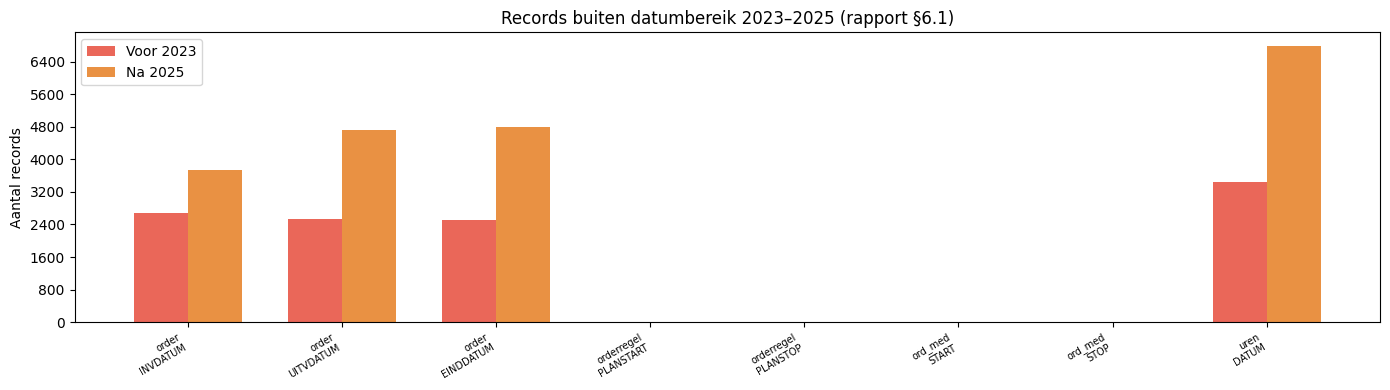

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
x, w = np.arange(len(bereik_df)), 0.35

ax.bar(x - w/2, bereik_df['voor_2023'], w, label='Voor 2023', color='#E74C3C', alpha=0.85)
ax.bar(x + w/2, bereik_df['na_2025'],   w, label='Na 2025',   color='#E67E22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(bereik_df['label'], fontsize=7, rotation=30, ha='right')
ax.set(ylabel='Aantal records', title='Records buiten datumbereik 2023–2025 (rapport §6.1)')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()

plt.tight_layout()
plt.savefig('nauwkeurigheid_datumbereik.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Taakoverlap — medewerker op twee plekken tegelijk

Als een medewerker twee overlappende toewijzingen heeft, klopt de planning niet.
Zie rapport §6.2 voor de bevindingen (0 overlaps gevonden).


In [ ]:
def prep_overlap(df_db):
    """Filter op rijen met geldige start/stop en een positief interval."""
    df = df_db.dropna(subset=['ORDMED_MEDID', 'ORDMED_PLAN_START', 'ORDMED_PLAN_STOP']).copy()
    df['ORDMED_PLAN_START'] = pd.to_datetime(df['ORDMED_PLAN_START'], errors='coerce')
    df['ORDMED_PLAN_STOP']  = pd.to_datetime(df['ORDMED_PLAN_STOP'],  errors='coerce')
    df = df.dropna(subset=['ORDMED_PLAN_START', 'ORDMED_PLAN_STOP'])
    return df[df['ORDMED_PLAN_START'] < df['ORDMED_PLAN_STOP']]


def tel_overlaps(df):
    """
    Tel overlappende intervals per medewerker.
    Sorteer op startdatum en kijk of de stop van stap i na de start van stap i+1 valt.
    """
    totaal = 0
    for _, grp in df.groupby('ORDMED_MEDID'):
        grp    = grp.sort_values('ORDMED_PLAN_START').reset_index(drop=True)
        stops  = grp['ORDMED_PLAN_STOP'].values[:-1]
        starts = grp['ORDMED_PLAN_START'].values[1:]
        totaal += int((stops > starts).sum())
    return totaal


overlap_data = []
for db in tabellen['ord_med']['con'].unique():
    db_df  = tabellen['ord_med'][tabellen['ord_med']['con'] == db]
    db_df  = prep_overlap(db_df)
    n_over = tel_overlaps(db_df)
    overlap_data.append({'db': db, 'overlaps': n_over, 'totaal': len(db_df)})

ov_df = pd.DataFrame(overlap_data)
ov_df['pct'] = (ov_df['overlaps'] / ov_df['totaal'] * 100).round(2)
print(ov_df.to_string(index=False))


          db  overlaps  totaal  pct
   23_hulter         0       0  NaN
   24_hulter         0       0  NaN
   25_hulter         0       0  NaN
 24_kuijpers         0       0  NaN
 25_kuijpers         0       0  NaN
    23_melse         0       0  NaN
    24_melse         0       0  NaN
    25_melse         0       0  NaN
     23_poel         0       0  NaN
     24_poel         0       0  NaN
     25_poel         0       0  NaN
   23_westra         0       0  NaN
   24_westra         0       0  NaN
   25_westra         0       0  NaN
23_jennissen         0       0  NaN
24_jennissen         0       0  NaN
25_jennissen         0       0  NaN
    23_derks         0       0  NaN
    24_derks         0       0  NaN
    25_derks         0       0  NaN


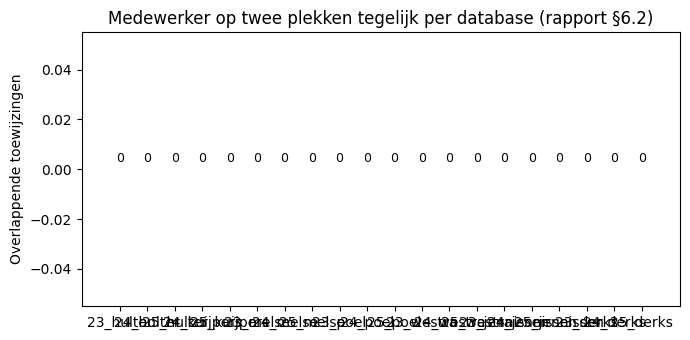

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(ov_df['db'], ov_df['overlaps'], color='#8E44AD', alpha=0.85)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set(ylabel='Overlappende toewijzingen',
       title='Medewerker op twee plekken tegelijk per database (rapport §6.2)')
plt.tight_layout()
plt.savefig('nauwkeurigheid_overlap.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Duurverdeling — uitbijters in gewerkte uren en mandagen

We kijken naar de verdeling van gewerkte uren (tijdsoort 3) en mandagen.
P99 = 13,25 uur is de uitbijtergrens voor Model 1. Zie rapport §6.3.


In [ ]:
uren_df  = tabellen['uren']

# Alleen tijdsoort 3 (directe werktijd), positieve waarden
uren_bew = (
    uren_df[uren_df['URENVERANTW_TIJDSOORT'] == 3]['URENVERANTW_AANTAL']
    .dropna()
    .pipe(lambda s: s[s > 0])
)

md_s = tabellen['ord_med']['ORDMED_MANDAGEN'].dropna().pipe(lambda s: s[s > 0])

# Statistieken voor in de figuur
n_neg_uren = int((uren_df['URENVERANTW_AANTAL'] < 0).sum())
n_boven24  = int((uren_df['URENVERANTW_AANTAL'] > 24).sum())
n_neg_md   = int((tabellen['ord_med']['ORDMED_MANDAGEN'] < 0).sum())

print(f'Uren  — negatief: {n_neg_uren} | > 24u: {n_boven24}')
print(f'Mand. — negatief: {n_neg_md}')

p99_uren = uren_bew.quantile(0.99)
print(f'P99 gewerkte uren (tijdsoort 3): {p99_uren:.2f} uur')


Uren  — negatief: 35 | > 24u: 89
Mand. — negatief: 2033
P99 gewerkte uren (tijdsoort 3): 14.50 uur


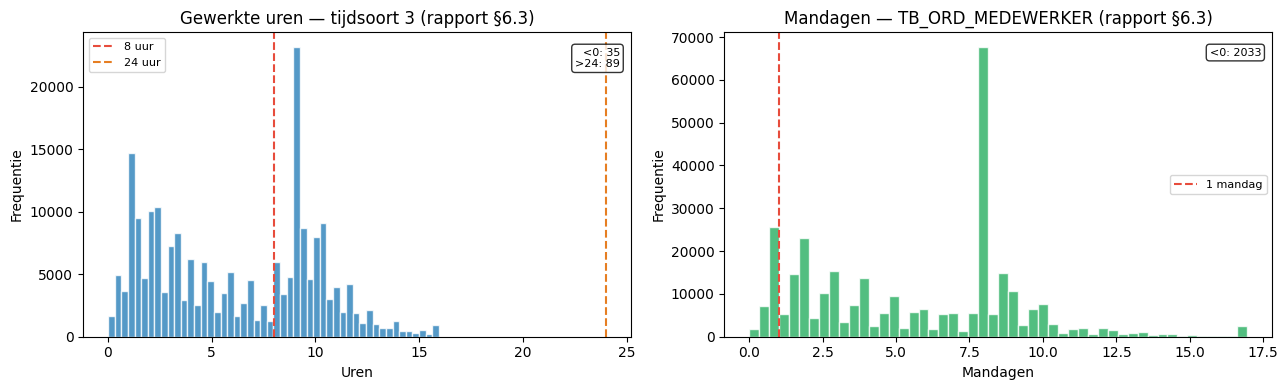

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram gewerkte uren — geclipt op 110% van P99 voor leesbaarheid
axes[0].hist(uren_bew.clip(upper=p99_uren * 1.1), bins=50,
             color='#2980B9', alpha=0.8, edgecolor='white')
axes[0].axvline(8,  color='#E74C3C', lw=1.5, ls='--', label='8 uur')
axes[0].axvline(24, color='#E67E22', lw=1.5, ls='--', label='24 uur')
axes[0].set(xlabel='Uren', ylabel='Frequentie',
            title='Gewerkte uren — tijdsoort 3 (rapport §6.3)')
axes[0].legend(fontsize=8)
axes[0].text(0.98, 0.95, f'<0: {n_neg_uren}\n>24: {n_boven24}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=8,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Histogram mandagen
p99_md = md_s.quantile(0.99)
axes[1].hist(md_s.clip(upper=p99_md * 1.1), bins=50,
             color='#27AE60', alpha=0.8, edgecolor='white')
axes[1].axvline(1, color='#E74C3C', lw=1.5, ls='--', label='1 mandag')
axes[1].set(xlabel='Mandagen', ylabel='Frequentie',
            title='Mandagen — TB_ORD_MEDEWERKER (rapport §6.3)')
axes[1].legend(fontsize=8)
axes[1].text(0.98, 0.95, f'<0: {n_neg_md}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=8,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('nauwkeurigheid_duurverdeling.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.4 Machine-koppeling via TF-IDF cosine similarity

Machine-velden zijn vrijwel leeg. We proberen machines te koppelen aan prijsregels
via tekstvergelijking (PRIJSRG_OMS ↔ MACH_OMS). De gelabelde records dienen als validatieset.
De analyse wordt uitgevoerd per database afzonderlijk.

**Bevinding (rapport §6.4):** Validatiescore varieert per database. Machine wordt buiten scope geplaatst.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Laad prijsregels met label (PRIJSRG_DEF_MACH_ID) en machines
prijs_df = fetch_combined(
    'TB_PRIJS_REGEL',
    'PRIJSRG_ID, PRIJSRG_OMS, PRIJSRG_ISDIENST, PRIJSRG_DEF_MACH_ID'
)
mach_df  = tabellen['machine'].drop_duplicates('MACH_ID')[['MACH_ID','MACH_OMS']].dropna()

# Bouw TF-IDF vectorruimte op karakter-n-grammen (3-4 tekens) van alle machine-namen
corpus      = mach_df['MACH_OMS'].str.lower().str.strip().tolist()
mach_ids    = mach_df['MACH_ID'].tolist()

vectorizer    = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4), min_df=1)
corpus_matrix = vectorizer.fit_transform(corpus)

print(f'Corpus: {len(corpus)} machines | Vectorruimte: {corpus_matrix.shape[1]} features')


Corpus: 1922 machines | Vectorruimte: 12491 features


**TF-IDF matching per database** — elke `PRIJSRG_OMS` wordt omgezet naar een vectorrepresentatie en vergeleken met het machine-corpus via cosine similarity. De beste match per prijsregel wordt opgeslagen. Daarna valideren we op de gelabelde records. Dit proces wordt uitgevoerd voor elke database afzonderlijk.

In [ ]:
uniek_prijs = (
    prijs_df
    .drop_duplicates('PRIJSRG_ID')[['PRIJSRG_ID','PRIJSRG_OMS','PRIJSRG_DEF_MACH_ID']]
    .copy()
)
uniek_prijs['PRIJSRG_OMS_clean'] = uniek_prijs['PRIJSRG_OMS'].str.lower().str.strip()

query_matrix = vectorizer.transform(uniek_prijs['PRIJSRG_OMS_clean'].fillna(''))
sim_matrix   = cosine_similarity(query_matrix, corpus_matrix)

# Pak de beste match per prijsregel
best_idx   = sim_matrix.argmax(axis=1)
best_score = sim_matrix.max(axis=1)

uniek_prijs['matched_mach_id']  = [mach_ids[i] for i in best_idx]
uniek_prijs['matched_mach_oms'] = [corpus[i]   for i in best_idx]
uniek_prijs['sim_score']        = best_score.round(3)

# Validatie: kloppen de matches op de 29 gelabelde records?
gelabeld = uniek_prijs[uniek_prijs['PRIJSRG_DEF_MACH_ID'].notna()].copy()
gelabeld['PRIJSRG_DEF_MACH_ID'] = gelabeld['PRIJSRG_DEF_MACH_ID'].astype(int)
gelabeld['correct'] = gelabeld['matched_mach_id'] == gelabeld['PRIJSRG_DEF_MACH_ID']

n_correct = gelabeld['correct'].sum()
print(f'Gelabelde records : {len(gelabeld)}')
print(f'Correct gematcht  : {n_correct} ({n_correct / len(gelabeld) * 100:.1f}%)')
print()
print(gelabeld[['PRIJSRG_OMS','matched_mach_oms','sim_score','correct']].to_string(index=False))


Gelabelde records : 232
Correct gematcht  : 35 (15.1%)

                                        PRIJSRG_OMS                      matched_mach_oms  sim_score  correct
                   Tractor 60-90 pk  + waterton 5m3                  tractor en bosklepel      0.381    False
                      Tractor 70 pk + klepelmaaier                           klepelmaaier      0.684    False
                                  Rupskraan 24 ton                          rupskraan 23t      0.722    False
                            8x4 vrachtwagen WS 43 t                 dieplader vrachtwagen      0.573    False
                            Midi-kraan 7 ton - rups                         rupskraan 23t      0.437    False
                               8x4 vrachtwagen 41 t                 dieplader vrachtwagen      0.594    False
                             Kippertrailer gestuurd               baggerkipper ongestuurd      0.572    False
                       Midi-kaan 6,5 ton mobiel dks             

**Validatie en drempel per database** — de minimale similarity-score bij correct gematche gelabelde records wordt als drempel gebruikt. We visualiseren de verdeling van alle scores en de uitkomst van de validatie voor elke database afzonderlijk.

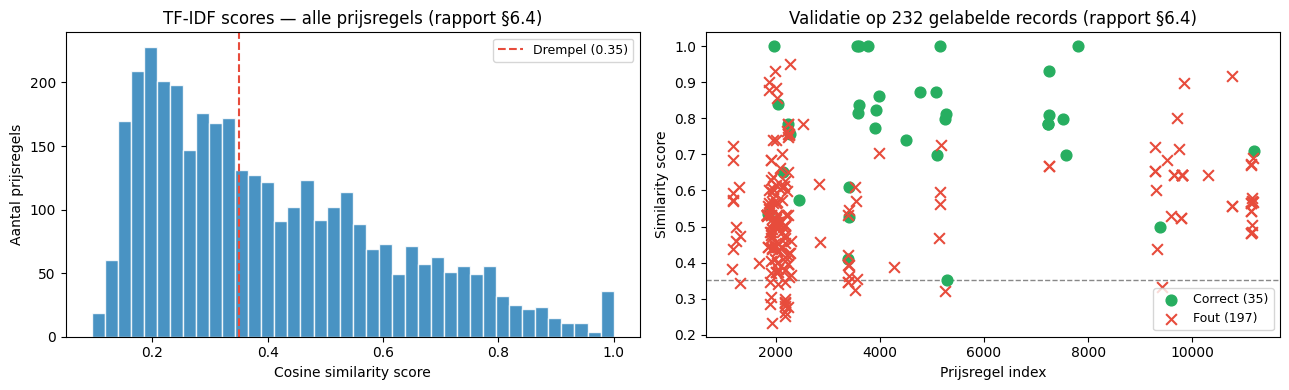

In [ ]:
drempel = gelabeld[gelabeld['correct']]['sim_score'].min() if n_correct > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Verdeling van alle similarity scores
axes[0].hist(uniek_prijs['sim_score'], bins=40, color='#2980B9', alpha=0.85, edgecolor='white')
if drempel > 0:
    axes[0].axvline(drempel, color='#E74C3C', lw=1.5, ls='--', label=f'Drempel ({drempel:.2f})')
    axes[0].legend(fontsize=9)
axes[0].set(xlabel='Cosine similarity score', ylabel='Aantal prijsregels',
            title='TF-IDF scores — alle prijsregels (rapport §6.4)')

# Scores van de gelabelde set
correct_scores = gelabeld[gelabeld['correct']]['sim_score']
fout_scores    = gelabeld[~gelabeld['correct']]['sim_score']
axes[1].scatter(correct_scores.index, correct_scores,
                color='#27AE60', label=f'Correct ({len(correct_scores)})', zorder=3, s=60)
axes[1].scatter(fout_scores.index, fout_scores,
                color='#E74C3C', label=f'Fout ({len(fout_scores)})', zorder=3, s=60, marker='x')
if drempel > 0:
    axes[1].axhline(drempel, color='#888', lw=1, ls='--')
axes[1].set(xlabel='Prijsregel index', ylabel='Similarity score',
            title=f'Validatie op {len(gelabeld)} gelabelde records (rapport §6.4)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('nauwkeurigheid_machine_vector.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Tijdigheid (Timeliness)

**Onderzoeksvraag (rapport §7):** Zijn er temporele gaten of verstoringen die de
representativiteit van de trainingsdata beïnvloeden?

Drie deelanalyses:
1. **Epoch-waarden** — Firebird gebruikt `1899-12-30` als null-placeholder voor datums
2. **Datadekking per database** — hoeveel maanden data heeft elke database?
3. **Temporele gaten** — zijn er maanden zonder registraties?
4. **Seizoenspatronen** — zijn de lage periodes (zomer, kerst) verklaarbaar?


### 5.1 Epoch-waarden (Firebird null-placeholders)

Firebird slaat lege datumvelden soms op als `1899-12-30` in plaats van `NULL`.
We filteren alles vóór 2000 als epoch-artifact. Zie rapport §7.1.


In [ ]:
EPOCH_GRENS   = pd.Timestamp('2000-01-01')
DATUM_KOLOMMEN = {
    'uren':       ['URENVERANTW_DATUM', 'URENVERANTW_STARTTIJD', 'URENVERANTW_STOPTIJD'],
    'order':      ['ORD_INVDATUM', 'ORD_UITVDATUM', 'ORD_EINDDATUM'],
    'orderregel': ['ORDRG_PLANSTART', 'ORDRG_PLANSTOP'],
    'ord_med':    ['ORDMED_PLAN_START', 'ORDMED_PLAN_STOP'],
    'project':    ['PROJ_STARTDT'],
}

epoch_summary = []

for tbl_key, kolommen in DATUM_KOLOMMEN.items():
    df = tabellen[tbl_key]
    for col in kolommen:
        if col not in df.columns:
            continue
        s = pd.to_datetime(df[col], errors='coerce')
        for db in sorted(df['con'].unique()):
            s_db    = s[df['con'] == db]
            n_tot   = int(s_db.notna().sum())
            n_epoch = int((s_db.notna() & (s_db < EPOCH_GRENS)).sum())
            if n_epoch > 0:
                epoch_summary.append({
                    'tabel': tbl_key, 'kolom': col, 'db': db,
                    'totaal': n_tot, 'epoch': n_epoch,
                    'pct': round(n_epoch / n_tot * 100, 2) if n_tot else 0,
                })

epoch_df = pd.DataFrame(epoch_summary)

if epoch_df.empty:
    print('✓ Geen epoch-waarden gevonden.')
else:
    print(f'Epoch-waarden in {epoch_df["kolom"].nunique()} kolom(men), '
          f'{epoch_df["db"].nunique()} database(s)\n')
    print(epoch_df[['tabel','kolom','db','totaal','epoch','pct']].to_string(index=False))
    print(f'\nTotaal epoch-records: {epoch_df["epoch"].sum():,}')


Epoch-waarden in 3 kolom(men), 11 database(s)

tabel             kolom           db  totaal  epoch  pct
 uren URENVERANTW_DATUM     23_derks   23082      1 0.00
 uren URENVERANTW_DATUM    23_hulter    9621      2 0.02
 uren URENVERANTW_DATUM 24_jennissen   67953      3 0.00
 uren URENVERANTW_DATUM  24_kuijpers   32429      1 0.00
 uren URENVERANTW_DATUM    24_westra   34047      3 0.01
 uren URENVERANTW_DATUM    25_hulter   11194      1 0.01
 uren URENVERANTW_DATUM 25_jennissen   76440      1 0.00
 uren URENVERANTW_DATUM     25_melse   34442      1 0.00
 uren URENVERANTW_DATUM      25_poel   13159      1 0.01
 uren URENVERANTW_DATUM    25_westra   37684      1 0.00
order     ORD_UITVDATUM 24_jennissen   27014      4 0.01
order     ORD_UITVDATUM  24_kuijpers   10950      1 0.01
order     ORD_UITVDATUM    24_westra   23006      1 0.00
order     ORD_UITVDATUM 25_jennissen   29612      1 0.00
order     ORD_UITVDATUM  25_kuijpers   13209      1 0.01
order     ORD_EINDDATUM 24_jennissen   27

**Epoch-heatmap** — we maken een pivot-tabel met als rijen de kolommen waar epoch-waarden zijn gevonden en als kolommen de databases. Zo zien we in één oogopslag waar het probleem het grootst is.

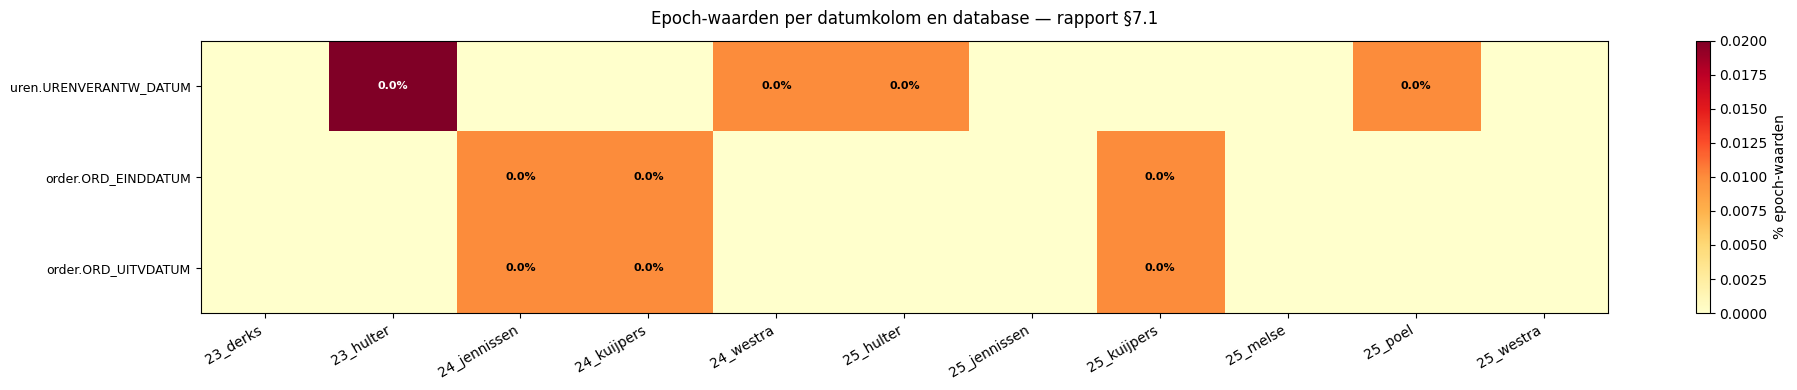

In [ ]:
if not epoch_df.empty:
    epoch_df['tabel_kolom'] = epoch_df['tabel'] + '.' + epoch_df['kolom']
    pivot = epoch_df.pivot_table(index='tabel_kolom', columns='db', values='pct', fill_value=0)
    pivot = pivot.assign(_som=pivot.sum(axis=1)).sort_values('_som', ascending=False).drop(columns='_som')
    
    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 1.8), max(4, len(pivot) * 0.6)))
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0)
    plt.colorbar(im, ax=ax, label='% epoch-waarden')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title('Epoch-waarden per datumkolom en database — rapport §7.1', fontsize=12, pad=12)
    for ri in range(len(pivot.index)):
        for ci in range(len(pivot.columns)):
            v = pivot.values[ri, ci]
            if v > 0:
                kleur = 'white' if v > pivot.values.max() * 0.6 else 'black'
                ax.text(ci, ri, f'{v:.1f}%', ha='center', va='center', fontsize=8,
                        color=kleur, fontweight='bold')
    plt.tight_layout()
    plt.savefig('tijdigheid_epoch_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


### 5.2 Registraties per maand per database

We filteren epoch-waarden (pre-2022) en tonen het patroon van urenregistraties per maand.
Rode verticale lijnen markeren maanden met < 10% van de mediaan. Zie rapport §7.2 en §7.3.


Epoch-filter: 7064 records verwijderd


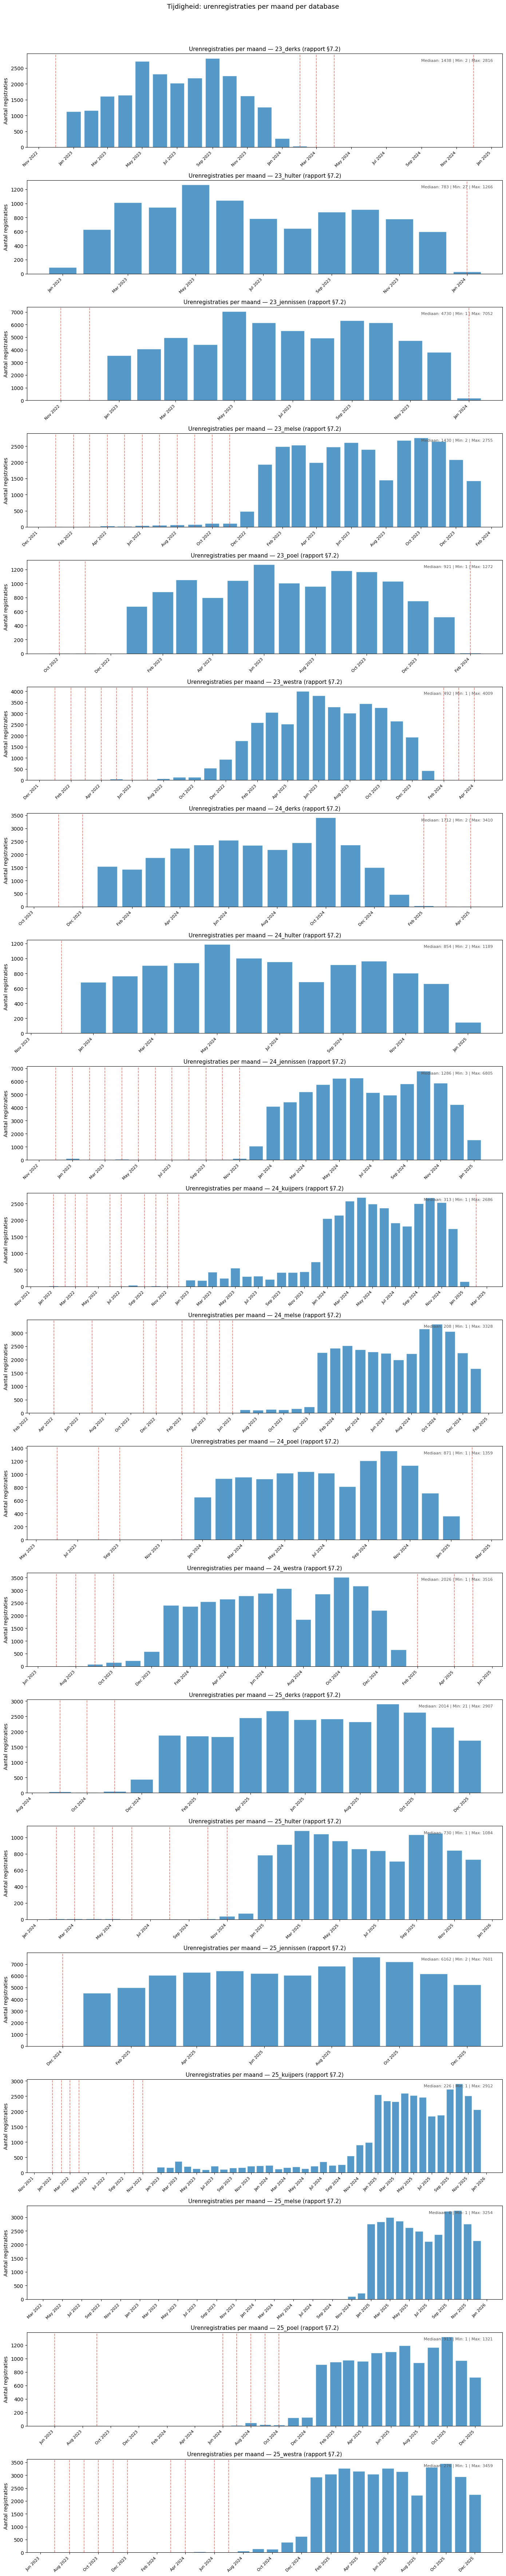

In [ ]:
DATE_FILTER_MIN = pd.Timestamp('2022-01-01')
DATE_FILTER_MAX = pd.Timestamp('2025-12-31')

# Urenregistraties voorbereiden (epoch eruit)
uren_tijd = tabellen['uren'].copy()
uren_tijd['datum'] = pd.to_datetime(uren_tijd['URENVERANTW_DATUM'], errors='coerce')
n_voor = len(uren_tijd)
uren_tijd = uren_tijd[uren_tijd['datum'].between(DATE_FILTER_MIN, DATE_FILTER_MAX)]
print(f'Epoch-filter: {n_voor - len(uren_tijd)} records verwijderd')

uren_tijd['jaar_maand'] = uren_tijd['datum'].dt.to_period('M')
db_volgorde = sorted(uren_tijd['con'].unique())

fig, axes = plt.subplots(len(db_volgorde), 1,
                          figsize=(14, 3.5 * len(db_volgorde)), sharex=False)
if len(db_volgorde) == 1:
    axes = [axes]

for ax, db in zip(axes, db_volgorde):
    subset = uren_tijd[uren_tijd['con'] == db]
    if subset.empty:
        ax.set_title(f'{db} — geen data'); continue
    
    maand_cnt = subset.groupby('jaar_maand').size()
    maand_cnt.index = maand_cnt.index.to_timestamp()
    
    ax.bar(maand_cnt.index, maand_cnt.values, width=25, color='#2980B9', alpha=0.8, edgecolor='white')
    ax.set_title(f'Urenregistraties per maand — {db} (rapport §7.2)', fontsize=11)
    ax.set_ylabel('Aantal registraties')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    
    # Markeer maanden met < 10% van de mediaan als potentieel gat
    mediaan = maand_cnt.median()
    for ts, val in maand_cnt[maand_cnt < mediaan * 0.1].items():
        ax.axvline(ts, color='#E74C3C', lw=1.2, ls='--', alpha=0.7)
    
    ax.text(0.98, 0.95, f'Mediaan: {mediaan:.0f} | Min: {maand_cnt.min()} | Max: {maand_cnt.max()}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#555')

plt.suptitle('Tijdigheid: urenregistraties per maand per database', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('tijdigheid_uren_per_maand.png', dpi=150, bbox_inches='tight')
plt.show()


**Temporele gaten** — we vergelijken de aanwezige maanden per database met het verwachte venster (2023-01 t/m 2025-12). Ontbrekende maanden worden gerapporteerd. Zie rapport §7.3 voor de bevindingen.

In [ ]:
VERWACHT_START = pd.Period('2023-01', freq='M')
VERWACHT_EIND  = pd.Period('2025-12', freq='M')

print('=== Temporele gaten in urenregistraties ===\n')

for db in db_volgorde:
    subset = uren_tijd[uren_tijd['con'] == db]
    if subset.empty:
        print(f'{db}: geen data\n'); continue
    
    maand_cnt    = subset.groupby('jaar_maand').size()
    start        = max(maand_cnt.index.min(), VERWACHT_START)
    eind         = min(maand_cnt.index.max(), VERWACHT_EIND)
    alle_maanden = pd.period_range(start=start, end=eind, freq='M')
    ontbrekend   = alle_maanden.difference(maand_cnt.index)
    
    print(f'Database: {db}  |  Periode: {start} t/m {eind}')
    print(f'  Verwacht: {len(alle_maanden)} maanden | Aanwezig: {len(maand_cnt)} | Ontbrekend: {len(ontbrekend)}')
    if len(ontbrekend) > 0:
        print(f'  Ontbrekende maanden: {", ".join(str(m) for m in ontbrekend[:10])}')
    else:
        print('  ✓ Geen gaten')
    print()

=== Temporele gaten in urenregistraties ===

Database: 23_derks  |  Periode: 2023-01 t/m 2024-12
  Verwacht: 24 maanden | Aanwezig: 18 | Ontbrekend: 7
  Ontbrekende maanden: 2024-05, 2024-06, 2024-07, 2024-08, 2024-09, 2024-10, 2024-11

Database: 23_hulter  |  Periode: 2023-01 t/m 2024-01
  Verwacht: 13 maanden | Aanwezig: 13 | Ontbrekend: 0
  ✓ Geen gaten

Database: 23_jennissen  |  Periode: 2023-01 t/m 2024-01
  Verwacht: 13 maanden | Aanwezig: 15 | Ontbrekend: 0
  ✓ Geen gaten

Database: 23_melse  |  Periode: 2023-01 t/m 2024-01
  Verwacht: 13 maanden | Aanwezig: 25 | Ontbrekend: 0
  ✓ Geen gaten

Database: 23_poel  |  Periode: 2023-01 t/m 2024-02
  Verwacht: 14 maanden | Aanwezig: 16 | Ontbrekend: 0
  ✓ Geen gaten

Database: 23_westra  |  Periode: 2023-01 t/m 2024-04
  Verwacht: 16 maanden | Aanwezig: 28 | Ontbrekend: 0
  ✓ Geen gaten

Database: 24_derks  |  Periode: 2023-11 t/m 2025-04
  Verwacht: 18 maanden | Aanwezig: 18 | Ontbrekend: 0
  ✓ Geen gaten

Database: 24_hulter  |  Pe

### 5.3 Seizoenspatronen

Lagere registraties in juli-augustus (zomervakantie) en december (kerst) zijn
verwachte bedrijfspatronen en worden niet gecorrigeerd. Ze worden meegenomen als
seizoenssignaal in de datumfeatures. Zie rapport §7.4.


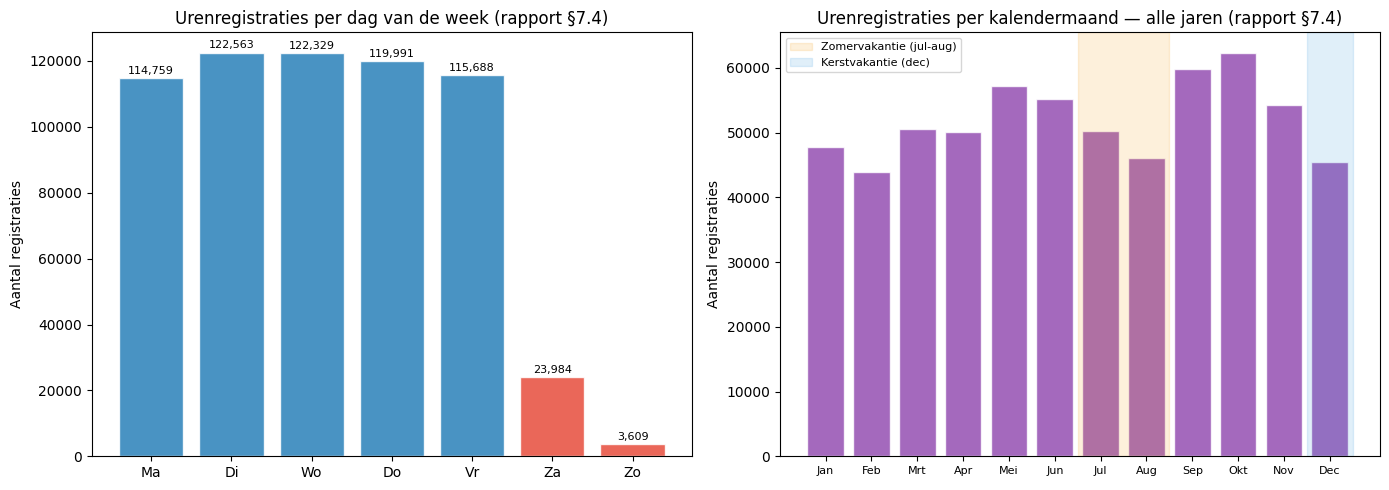

In [ ]:
uren_seis = uren_tijd.copy()
uren_seis['dag_week'] = uren_seis['datum'].dt.dayofweek  # 0=maandag
uren_seis['maand_nr'] = uren_seis['datum'].dt.month

dag_cnt   = uren_seis.groupby('dag_week').size()
maand_cnt_all = uren_seis.groupby('maand_nr').size()

dag_namen   = ['Ma','Di','Wo','Do','Vr','Za','Zo']
maand_namen = ['Jan','Feb','Mrt','Apr','Mei','Jun','Jul','Aug','Sep','Okt','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per dag — weekend rood
kleuren_dag = ['#2980B9'] * 5 + ['#E74C3C'] * 2
axes[0].bar(dag_cnt.index, dag_cnt.values, color=kleuren_dag, alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(7)); axes[0].set_xticklabels(dag_namen)
axes[0].set(title='Urenregistraties per dag van de week (rapport §7.4)',
            ylabel='Aantal registraties')
for i, v in enumerate(dag_cnt.values):
    axes[0].text(i, v + dag_cnt.max() * 0.01, f'{v:,}', ha='center', fontsize=8)

# Per maand — met vakantiemarkering
axes[1].bar(maand_cnt_all.index, maand_cnt_all.values, color='#8E44AD', alpha=0.8, edgecolor='white')
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(maand_namen, fontsize=8)
axes[1].set(title='Urenregistraties per kalendermaand — alle jaren (rapport §7.4)',
            ylabel='Aantal registraties')
axes[1].axvspan(6.5,  8.5, color='#F39C12', alpha=0.15, label='Zomervakantie (jul-aug)')
axes[1].axvspan(11.5, 12.5, color='#3498DB', alpha=0.15, label='Kerstvakantie (dec)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('tijdigheid_seizoen.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Bruikbaarheid voor de ML-modellen

**Onderzoeksvraag (rapport §8):** Welke tabellen en velden leveren bruikbare features op
voor Model 1 (tijdsvoorspelling) en Model 2 (resource-matching)?

Vijf deelanalyses:
1. **Tijdsoort-verdeling** — welk aandeel is tijdsoort 3 (de target variable)?
2. **Verdeling target variable** — is de verdeling bruikbaar voor een regressiemodel?
3. **Koppelketen volledigheid** — hoeveel records overleven alle join-stappen?
4. **Feature beschikbaarheid** — welke features zijn beschikbaar per model?
5. **Medewerker-activiteit dekking** — hoe breed is de dekking voor Model 2?


### 6.1 Tijdsoort-verdeling

Tijdsoort 3 (Bewerking = directe werktijd) is de target variable voor Model 1.
De overige tijdsoorten zijn nodig om bruto naar netto tijd te berekenen.
Zie rapport §8.1.


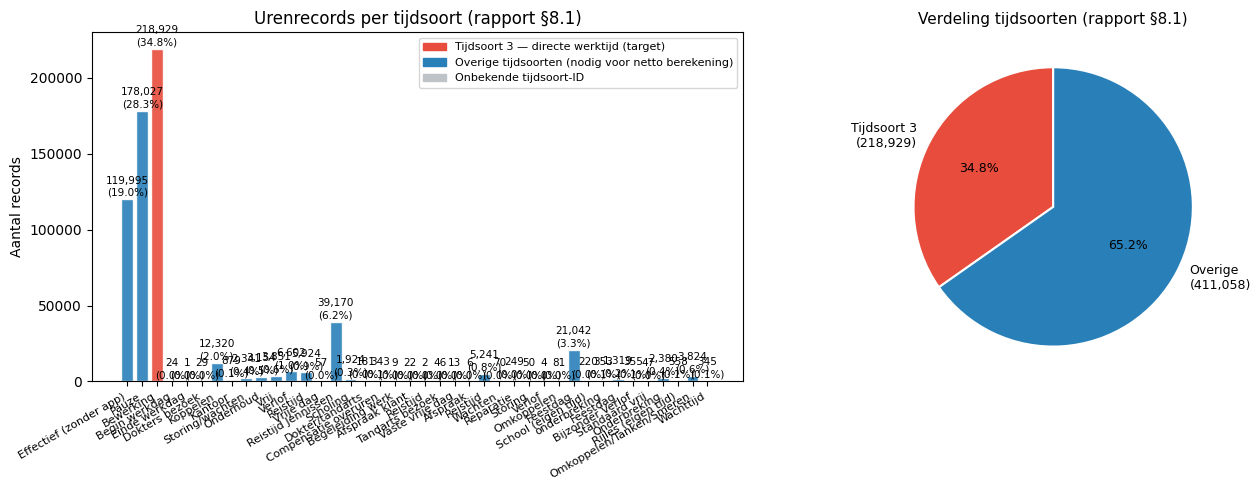

Tijdsoort 3 (target): 218,929 records (34.8%)
Overige tijdsoorten : 411,058


In [ ]:
uren_df = tabellen['uren'].copy()

# Haal echte omschrijvingen op uit TB_TIJDSOORT
ts_tabel = tabellen['tijdsoort'][['TIJDSOORT_ID','TIJDSOORT_OMS']].drop_duplicates()
ts_map   = dict(zip(ts_tabel['TIJDSOORT_ID'], ts_tabel['TIJDSOORT_OMS']))

ts_counts = uren_df['URENVERANTW_TIJDSOORT'].value_counts().sort_index()

TARGET_ID   = 3
BEKENDE_IDS = set(ts_map.keys())

# Kleur per tijdsoort: rood = target, blauw = overig bekend, grijs = onbekend
def tijdsoort_kleur(k):
    if pd.isna(k):        return '#95A5A6'
    if int(k) == TARGET_ID: return '#E74C3C'
    if int(k) in BEKENDE_IDS: return '#2980B9'
    return '#BDC3C7'

kleuren = [tijdsoort_kleur(k) for k in ts_counts.index]
labels  = [ts_map.get(k, f'Tijdsoort {int(k)}') if pd.notna(k) else 'Onbekend'
           for k in ts_counts.index]

n_target = int(ts_counts.get(TARGET_ID, 0))
n_overig = int(sum(v for k, v in zip(ts_counts.index, ts_counts.values)
                   if pd.notna(k) and int(k) in BEKENDE_IDS and int(k) != TARGET_ID))
n_onbek  = int(ts_counts.sum()) - n_target - n_overig

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Staafdiagram
bars = axes[0].bar(range(len(ts_counts)), ts_counts.values, color=kleuren, alpha=0.9, edgecolor='white')
axes[0].set_xticks(range(len(ts_counts))); axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
axes[0].set(ylabel='Aantal records', title='Urenrecords per tijdsoort (rapport §8.1)')
for i, v in enumerate(ts_counts.values):
    axes[0].text(i, v + ts_counts.max() * 0.01, f'{v:,}\n({v/ts_counts.sum()*100:.1f}%)',
                 ha='center', fontsize=7.5, linespacing=1.3)

legenda = [
    mpatches.Patch(color='#E74C3C', label='Tijdsoort 3 — directe werktijd (target)'),
    mpatches.Patch(color='#2980B9', label='Overige tijdsoorten (nodig voor netto berekening)'),
    mpatches.Patch(color='#BDC3C7', label='Onbekende tijdsoort-ID'),
]
axes[0].legend(handles=legenda, fontsize=8)

# Taartdiagram
taart_vals   = [n_target, n_overig]
taart_labels = [f'Tijdsoort 3\n({n_target:,})', f'Overige\n({n_overig:,})']
taart_kleuren= ['#E74C3C', '#2980B9']
if n_onbek > 0:
    taart_vals.append(n_onbek)
    taart_labels.append(f'Onbekend\n({n_onbek:,})')
    taart_kleuren.append('#BDC3C7')

axes[1].pie(taart_vals, labels=taart_labels, colors=taart_kleuren,
            startangle=90, autopct='%1.1f%%', textprops={'fontsize': 9},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Verdeling tijdsoorten (rapport §8.1)', fontsize=11)

plt.tight_layout()
plt.savefig('bruikbaarheid_tijdsoort.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Tijdsoort 3 (target): {n_target:,} records ({n_target/ts_counts.sum()*100:.1f}%)')
print(f'Overige tijdsoorten : {n_overig:,}')


### 6.2 Verdeling target variable

We tonen de verdeling van gewerkte uren (tijdsoort 3) als histogram en boxplot per database.
De mediaan van 5,5 uur en de consistente verdeling over alle databases zijn positief (rapport §8.2).


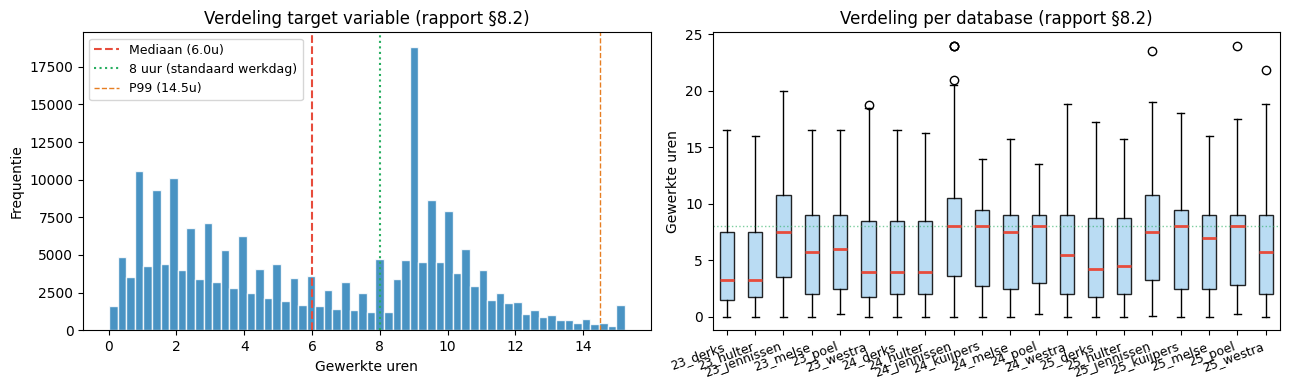

N       : 218,070
Mediaan : 6.00 uur
Q25-Q75 : 2.50 – 9.50 uur
P99     : 14.50 uur  ← uitbijtergrens voor cleaning


In [ ]:
uren_bew = (
    uren_df[uren_df['URENVERANTW_TIJDSOORT'] == 3]['URENVERANTW_AANTAL']
    .dropna().pipe(lambda s: s[s > 0])
)

p25, p50, p75, p99 = uren_bew.quantile([0.25, 0.50, 0.75, 0.99])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(uren_bew.clip(upper=p99 * 1.05), bins=60, color='#2980B9', alpha=0.85, edgecolor='white')
axes[0].axvline(p50, color='#E74C3C', lw=1.5, ls='--', label=f'Mediaan ({p50:.1f}u)')
axes[0].axvline(8,   color='#27AE60', lw=1.5, ls=':',  label='8 uur (standaard werkdag)')
axes[0].axvline(p99, color='#E67E22', lw=1,   ls='--', label=f'P99 ({p99:.1f}u)')
axes[0].set(xlabel='Gewerkte uren', ylabel='Frequentie',
            title='Verdeling target variable (rapport §8.2)')
axes[0].legend(fontsize=9)

# Boxplot per database
db_namen = sorted(uren_df['con'].unique())
data_per_db = [
    uren_df[(uren_df['URENVERANTW_TIJDSOORT'] == 3) & (uren_df['con'] == db)]['URENVERANTW_AANTAL']
    .dropna().pipe(lambda s: s[s > 0]).values
    for db in db_namen
]
bp = axes[1].boxplot(data_per_db, labels=db_namen, patch_artist=True,
                      medianprops={'color': '#E74C3C', 'lw': 2})
for patch in bp['boxes']:
    patch.set_facecolor('#AED6F1'); patch.set_alpha(0.85)
axes[1].set(ylabel='Gewerkte uren', title='Verdeling per database (rapport §8.2)')
axes[1].set_xticklabels(db_namen, rotation=20, ha='right', fontsize=9)
axes[1].axhline(8, color='#27AE60', lw=1, ls=':', alpha=0.6)

plt.tight_layout()
plt.savefig('bruikbaarheid_target_verdeling.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'N       : {len(uren_bew):,}')
print(f'Mediaan : {p50:.2f} uur')
print(f'Q25-Q75 : {p25:.2f} – {p75:.2f} uur')
print(f'P99     : {p99:.2f} uur  ← uitbijtergrens voor cleaning')


### 6.3 Koppelketen volledigheid

We testen stap voor stap hoeveel urenrecords de volledige koppelketen overleven
(uren → order_da → order → dienst_artikel → medewerker). Kleur geeft het verlies aan.
Zie rapport §8.3.


**Koppelketen opbouwen** — we beginnen met alle urenrecords van tijdsoort 3 met een positief uurtal en voegen stap voor stap de benodigde tabellen toe via joins. Na elke stap registreren we hoeveel records overblijven.

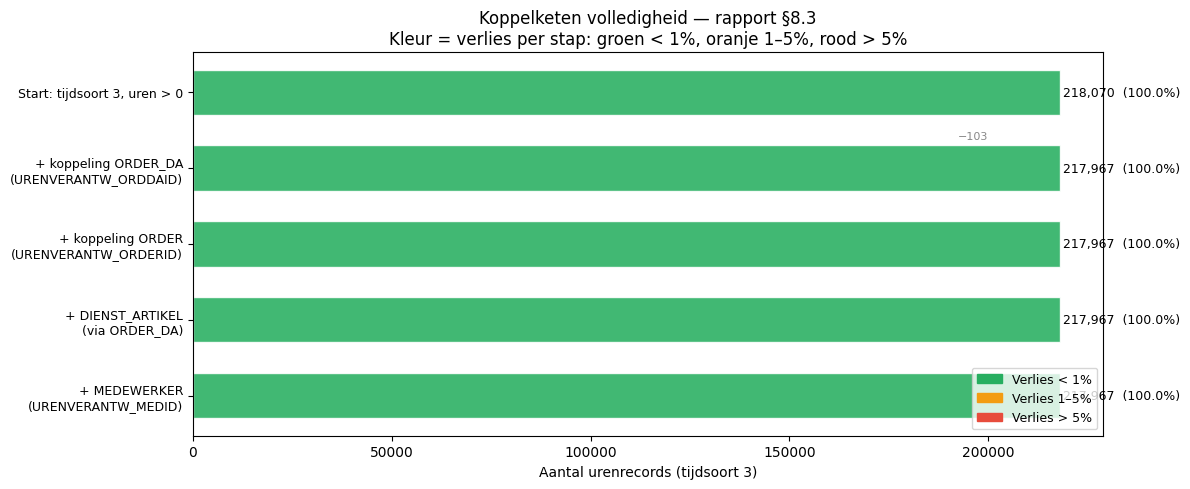

In [ ]:
start = uren_df[(uren_df['URENVERANTW_TIJDSOORT'] == 3) & (uren_df['URENVERANTW_AANTAL'] > 0)].copy()
n_start = len(start)

stappen = [('Start: tijdsoort 3, uren > 0', n_start)]

# Stap 1: koppeling naar TB_ORDER_DA
s1 = start.dropna(subset=['URENVERANTW_ORDDAID'])
s1 = s1[s1['URENVERANTW_ORDDAID'].isin(tabellen['order_da']['ORDER_DA_ID'])]
stappen.append(('+ koppeling ORDER_DA\n(URENVERANTW_ORDDAID)', len(s1)))

# Stap 2: koppeling naar TB_ORDER
s2 = s1[s1['URENVERANTW_ORDERID'].isin(tabellen['order']['ORD_ID'])]
stappen.append(('+ koppeling ORDER\n(URENVERANTW_ORDERID)', len(s2)))

# Stap 3: DIENST_ARTIKEL via ORDER_DA (nodig voor activiteitstype als feature)
oda_met_da = tabellen['order_da'].dropna(subset=['DIENST_ART_ID'])
s3 = s2[s2['URENVERANTW_ORDDAID'].isin(oda_met_da['ORDER_DA_ID'])]
stappen.append(('+ DIENST_ARTIKEL\n(via ORDER_DA)', len(s3)))

# Stap 4: koppeling naar TB_MEDEWERKER
s4 = s3[s3['URENVERANTW_MEDID'].isin(tabellen['medewerker']['MED_ID'])]
stappen.append(('+ MEDEWERKER\n(URENVERANTW_MEDID)', len(s4)))

labels_k = [s[0] for s in stappen]
counts_k = [s[1] for s in stappen]
pcts     = [c / n_start * 100 for c in counts_k]

# Kleur op basis van verlies per stap ten opzichte van startpunt
def stap_kleur(i):
    if i == 0: return '#27AE60'
    verlies = (counts_k[i-1] - counts_k[i]) / n_start * 100
    if verlies < 1:   return '#27AE60'   # < 1% verlies = groen
    elif verlies < 5: return '#F39C12'   # 1-5% = oranje
    else:             return '#E74C3C'   # > 5% = rood

kleuren_k = [stap_kleur(i) for i in range(len(stappen))]

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(range(len(stappen)), counts_k, color=kleuren_k, alpha=0.88, edgecolor='white', height=0.6)
ax.set_yticks(range(len(stappen))); ax.set_yticklabels(labels_k, fontsize=9)
ax.invert_yaxis()
ax.set(xlabel='Aantal urenrecords (tijdsoort 3)',
       title='Koppelketen volledigheid — rapport §8.3\n'
             'Kleur = verlies per stap: groen < 1%, oranje 1–5%, rood > 5%')

for i, (n, pct) in enumerate(zip(counts_k, pcts)):
    ax.text(n + n_start * 0.004, i, f'{n:,}  ({pct:.1f}%)', va='center', fontsize=9)

for i in range(1, len(stappen)):
    uitval = counts_k[i-1] - counts_k[i]
    if uitval > 0:
        ax.annotate(f'−{uitval:,}',
                    xy=(counts_k[i], i),
                    xytext=(counts_k[i] - n_start * 0.1, i - 0.38),
                    fontsize=8, color='#888', ha='center')

legenda = [
    mpatches.Patch(color='#27AE60', label='Verlies < 1%'),
    mpatches.Patch(color='#F39C12', label='Verlies 1–5%'),
    mpatches.Patch(color='#E74C3C', label='Verlies > 5%'),
]
ax.legend(handles=legenda, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('bruikbaarheid_koppelketen.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4 Feature beschikbaarheid per model

Overzicht van alle features: vulgraad en relevantie per model.
Groen = ≥95% gevuld, oranje = 80-95%, rood = <80%. Zie rapport §8.4.


**Feature-definitie** — voor elke feature leggen we vast: de brpontabel, de vulgraad (uit de volledigheidsanalyse in §2), en of de feature relevant is voor Model 1 (tijdsvoorspelling) en/of Model 2 (resource-matching).

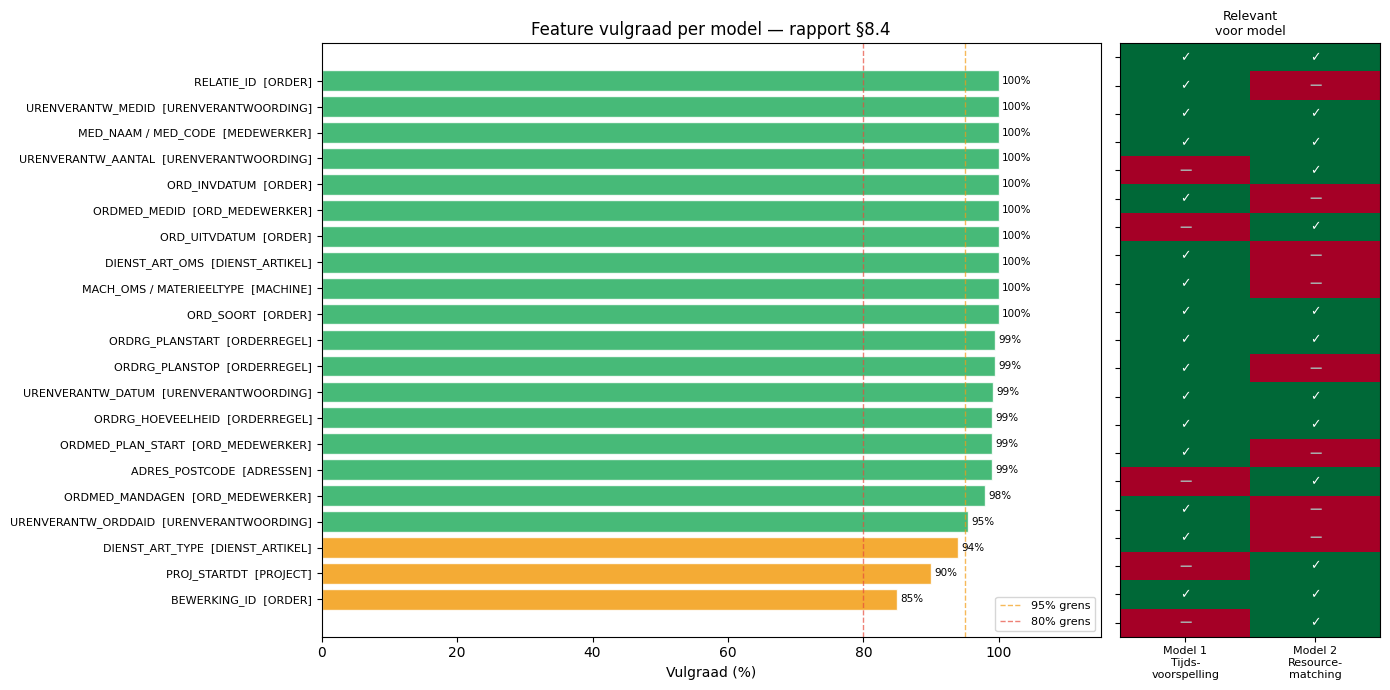

Model 1 features : 16
Model 2 features : 13
Gedeeld          : 8


In [ ]:
FEATURES = [
    # (feature, tabel, vulgraad%, model1, model2)
    ('URENVERANTW_DATUM',       'TB_URENVERANTWOORDING', 99.1, True,  False),
    ('URENVERANTW_MEDID',       'TB_URENVERANTWOORDING', 100,  True,  True),
    ('URENVERANTW_ORDDAID',     'TB_URENVERANTWOORDING', 95.4, True,  True),
    ('URENVERANTW_AANTAL',      'TB_URENVERANTWOORDING', 100,  True,  False),
    ('ORD_INVDATUM',            'TB_ORDER',              100,  True,  False),
    ('ORD_UITVDATUM',           'TB_ORDER',              100,  True,  False),
    ('ORD_SOORT',               'TB_ORDER',              100,  True,  False),
    ('BEWERKING_ID',            'TB_ORDER',              85,   True,  True),
    ('RELATIE_ID',              'TB_ORDER',              100,  False, True),
    ('ORDRG_HOEVEELHEID',       'TB_ORDERREGEL',         99,   True,  False),
    ('ORDRG_PLANSTART',         'TB_ORDERREGEL',         99.4, True,  True),
    ('ORDRG_PLANSTOP',          'TB_ORDERREGEL',         99.4, True,  True),
    ('DIENST_ART_OMS',          'TB_DIENST_ARTIKEL',     100,  True,  True),
    ('DIENST_ART_TYPE',         'TB_DIENST_ARTIKEL',     94,   True,  True),
    ('ORDMED_MEDID',            'TB_ORD_MEDEWERKER',     100,  False, True),
    ('ORDMED_PLAN_START',       'TB_ORD_MEDEWERKER',     99,   False, True),
    ('ORDMED_MANDAGEN',         'TB_ORD_MEDEWERKER',     98,   False, True),
    ('MED_NAAM / MED_CODE',     'TB_MEDEWERKER',         100,  False, True),
    ('ADRES_POSTCODE',          'TB_ADRESSEN',           99,   True,  False),
    ('MACH_OMS / MATERIEELTYPE','TB_MACHINE',            100,  True,  True),
    ('PROJ_STARTDT',            'TB_PROJECT',            90,   True,  False),
]

df_feat = pd.DataFrame(FEATURES, columns=['feature','tabel','vulgraad','model1','model2'])
df_feat = df_feat.sort_values('vulgraad', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [3, 1]})

# Horizontale balkgrafiek — vulgraad per feature
kleuren_vul = ['#E74C3C' if v < 80 else '#F39C12' if v < 95 else '#27AE60'
                for v in df_feat['vulgraad']]
axes[0].barh(range(len(df_feat)), df_feat['vulgraad'], color=kleuren_vul, alpha=0.85, edgecolor='white')
axes[0].set_yticks(range(len(df_feat)))
axes[0].set_yticklabels([f'{r.feature}  [{r.tabel.replace("TB_","")}]'
                          for _, r in df_feat.iterrows()], fontsize=8)
axes[0].set_xlim(0, 115)
axes[0].axvline(95, color='#F39C12', lw=1, ls='--', alpha=0.7, label='95% grens')
axes[0].axvline(80, color='#E74C3C', lw=1, ls='--', alpha=0.7, label='80% grens')
axes[0].set(xlabel='Vulgraad (%)', title='Feature vulgraad per model — rapport §8.4')
axes[0].legend(fontsize=8)
for i, v in enumerate(df_feat['vulgraad']):
    axes[0].text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=7.5)

# Relevantie-matrix rechts
matrix = df_feat[['model1','model2']].values.astype(int)
axes[1].imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Model 1\nTijds-\nvoorspelling', 'Model 2\nResource-\nmatching'], fontsize=8)
axes[1].set_yticks(range(len(df_feat))); axes[1].set_yticklabels([])
axes[1].set_title('Relevant\nvoor model', fontsize=9)
for ri in range(len(df_feat)):
    for ci in range(2):
        v = matrix[ri, ci]
        axes[1].text(ci, ri, '✓' if v else '—', ha='center', va='center',
                     fontsize=9, color='white' if v else '#aaa', fontweight='bold')

plt.tight_layout()
plt.savefig('bruikbaarheid_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Model 1 features : {df_feat["model1"].sum()}')
print(f'Model 2 features : {df_feat["model2"].sum()}')
print(f'Gedeeld          : {(df_feat["model1"] & df_feat["model2"]).sum()}')


### 6.5 Medewerker-activiteit dekking (Model 2)

Voor resource-matching moeten we weten welke medewerkers welke activiteiten uitvoeren.
65 activiteiten (20,8%) zijn door slechts 1 medewerker uitgevoerd — dit vereist een
fallback-strategie op basis van functieprofiel. Zie rapport §8.5.


**Koppelketen voor Model 2** — om medewerker-activiteit paren te analyseren joinen we de urenregistraties (tijdsoort 3) via `TB_ORDER_DA` naar `TB_DIENST_ARTIKEL`. Zo weten we welke medewerker welke activiteit heeft uitgevoerd.

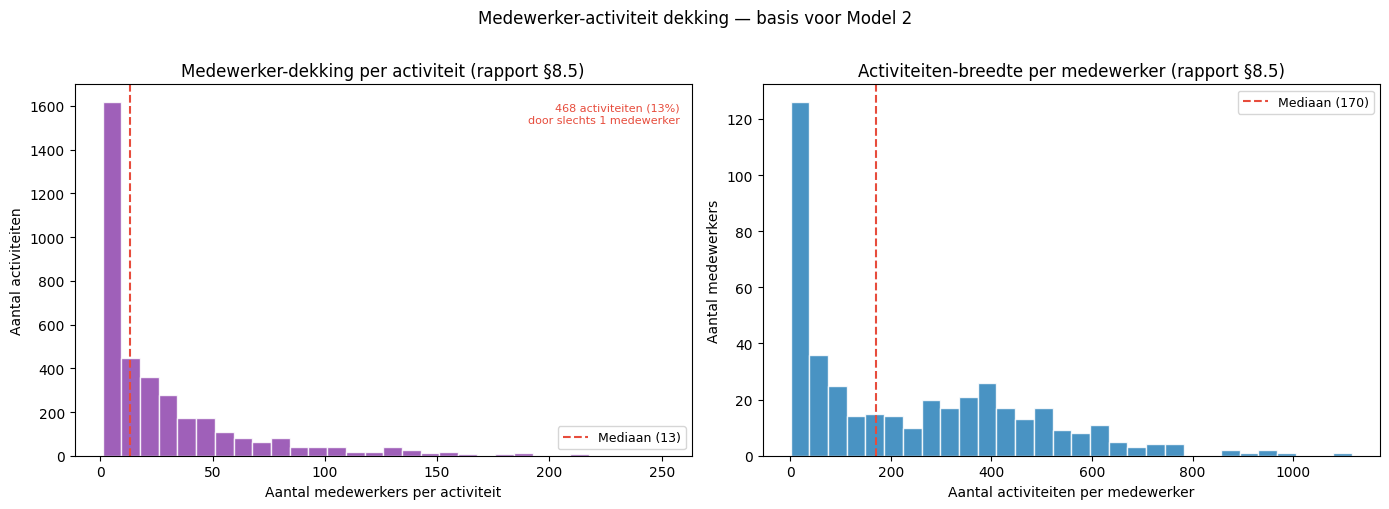

Unieke activiteiten: 3,665
Unieke medewerkers : 422
Activiteiten door 1 medewerker: 468 (12.8%)
Mediaan medewerkers/activiteit: 13


In [ ]:
uren_t3 = uren_df[uren_df['URENVERANTW_TIJDSOORT'] == 3].dropna(
    subset=['URENVERANTW_ORDDAID', 'URENVERANTW_MEDID']
)
oda = tabellen['order_da'][['ORDER_DA_ID','DIENST_ART_ID']].dropna()
da  = tabellen['dienst_art'][['DIENST_ART_ID','DIENST_ART_OMS']].dropna()

joined = (
    uren_t3
    .merge(oda, left_on='URENVERANTW_ORDDAID', right_on='ORDER_DA_ID', how='inner')
    .merge(da,  on='DIENST_ART_ID', how='inner')
)

# Medewerkers per activiteit en activiteiten per medewerker
med_per_act = joined.groupby('DIENST_ART_OMS')['URENVERANTW_MEDID'].nunique().sort_values(ascending=False)
act_per_med = joined.groupby('URENVERANTW_MEDID')['DIENST_ART_OMS'].nunique().sort_values(ascending=False)

n_single = int((med_per_act == 1).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(med_per_act.values, bins=30, color='#8E44AD', alpha=0.85, edgecolor='white')
axes[0].axvline(med_per_act.median(), color='#E74C3C', lw=1.5, ls='--',
                label=f'Mediaan ({med_per_act.median():.0f})')
axes[0].set(xlabel='Aantal medewerkers per activiteit', ylabel='Aantal activiteiten',
            title='Medewerker-dekking per activiteit (rapport §8.5)')
axes[0].legend(fontsize=9)
axes[0].text(0.98, 0.95,
             f'{n_single} activiteiten ({n_single/len(med_per_act)*100:.0f}%)\ndoor slechts 1 medewerker',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=8, color='#E74C3C')

axes[1].hist(act_per_med.values, bins=30, color='#2980B9', alpha=0.85, edgecolor='white')
axes[1].axvline(act_per_med.median(), color='#E74C3C', lw=1.5, ls='--',
                label=f'Mediaan ({act_per_med.median():.0f})')
axes[1].set(xlabel='Aantal activiteiten per medewerker', ylabel='Aantal medewerkers',
            title='Activiteiten-breedte per medewerker (rapport §8.5)')
axes[1].legend(fontsize=9)

plt.suptitle('Medewerker-activiteit dekking — basis voor Model 2', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('bruikbaarheid_medewerker_activiteit.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Unieke activiteiten: {len(med_per_act):,}')
print(f'Unieke medewerkers : {len(act_per_med):,}')
print(f'Activiteiten door 1 medewerker: {n_single:,} ({n_single/len(med_per_act)*100:.1f}%)')
print(f'Mediaan medewerkers/activiteit: {med_per_act.median():.0f}')


## 7. Samenvatting en cleaning-pipeline

**Conclusie (rapport §10):** De dataset is van voldoende kwaliteit voor beide modellen.
Geen showstoppers gevonden. Na de cleaning-pipeline zijn ~36.300 records beschikbaar.

### Cleaning-pipeline (rapport §9)

De volgorde is bewust — elke stap bouwt voort op de vorige:

| Stap | Actie | Reden |
|------|-------|-------|
| 1 | Filter epoch-datums (< 2000), negatieve uren, records zonder ORDER_DA_ID | Onbetrouwbare waarden |
| 2 | Dedupliceer urenregistraties per medewerker/order_da/datum (uren optellen) | Dubbele invoer |
| 3 | Filter op tijdsoort 3 voor Model 1-trainingsrijen | Target variable selectie |
| 4 | Markeer uitbijters boven P99 (13,25 uur) met een vlag | Robuustheid model |
| 5 | Imputeer BEWERKING_ID via DIENST_ARTIKEL-route | Feature beschikbaarheid |
| 6 | Transformeer datumvelden naar cyclische features (dag, maand, bouwvak-indicator) | Tijdpatronen |

Na deze stappen: **~36.300 trainingsrecords voor Model 1** en **~36.300 medewerker-activiteit combinaties voor Model 2**.
